# Electricity Price Analysis in France 🇫🇷

## 🎯 Objective
This project investigates the key drivers of electricity price fluctuations in France, focusing on demand patterns and renewable energy production.

## ❓ Key Questions
- What temporal patterns (hourly, weekly, seasonal) affect electricity prices?
- How do demand (load) and renewable generation (wind, solar) influence prices?
- What conditions lead to extreme price spikes?

## 📊 Dataset
- Electricity price (€/MWh)
- Load (demand)
- Wind generation
- Solar generation

Time resolution: hourly

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

In [2]:
price_files = sorted(glob.glob("../data/raw/GUI_ENERGY_PRICES_*.csv"))
load_files = sorted(glob.glob("../data/raw/GUI_TOTAL_LOAD_DAYAHEAD_*.csv"))
wind_off_shore_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_OFFSHORE_*.csv"))
wind_on_shore_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_*.csv"))
solar_files = sorted(glob.glob("../data/raw/GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_*.csv"))

In [3]:
def read_to_df(file):
    dfs = []
    for f in file:
        df = pd.read_csv(f)
        dfs.append(df)
    df_concat = pd.concat(dfs)
    return df_concat

In [4]:
df1 = read_to_df(price_files[0:9])
df2 = read_to_df(load_files[0:9])
df3 = read_to_df(wind_off_shore_files[0:9])
df4 = read_to_df(wind_on_shore_files[0:9])
df5 = read_to_df(solar_files[0:9])

In [5]:
df1.drop(["Sequence", "Intraday Period (CET/CEST)", "Intraday Price (EUR/MWh)"], axis = 1, inplace = True)
df1.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41


In [6]:
df2.drop("Area", axis = 1, inplace = True)
df2.head()

,MTU (CET/CEST),Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2016 00:00 - 01/01/2016 01:00,58639.0,58600.0
1,01/01/2016 01:00 - 01/01/2016 02:00,56733.0,56550.0
2,01/01/2016 02:00 - 01/01/2016 03:00,55127.0,56150.0
3,01/01/2016 03:00 - 01/01/2016 04:00,51744.0,52600.0
4,01/01/2016 04:00 - 01/01/2016 05:00,51744.0,49750.0


In [7]:
def format_mtu(mtu_string):
    start, end = mtu_string.split(" - ")
    
    def process_part(part):
        # Extract timezone if exists
        match = re.match(r"(.+?)(\s\(.+\))?$", part)
        datetime_part = match.group(1)
        tz_part = match.group(2) if match.group(2) else ""
        
        # Convert to datetime and format with seconds
        dt = pd.to_datetime(datetime_part, format="%d/%m/%Y %H:%M")
        return dt.strftime("%d/%m/%Y %H:%M:%S") + tz_part
    
    return process_part(start) + " - " + process_part(end)

df2["MTU (CET/CEST)"] = df2["MTU (CET/CEST)"].apply(format_mtu)

df2.head()

,MTU (CET/CEST),Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,58639.0,58600.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,56733.0,56550.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,55127.0,56150.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,51744.0,52600.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,51744.0,49750.0


In [8]:
df3.drop("Area", axis = 1, inplace = True)
df3[["Day-ahead (MW)", "Intraday (MW)", "Actual (MW)"]] = df3[["Day-ahead (MW)", "Intraday (MW)", "Actual (MW)"]].replace("n/e", np.nan)
df3.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,NaN,NaN,,NaN
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,NaN,NaN,,NaN
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,NaN,NaN,,NaN
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,NaN,NaN,,NaN
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,NaN,NaN,,NaN


In [9]:
df4.drop("Area", axis = 1, inplace = True)
df4.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,2313.42,NaN,,2189.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,2003.04,NaN,,1753.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,1743.72,NaN,,1430.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,1490.09,NaN,,1214.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,1238.09,NaN,,1031.0


In [10]:
df5.drop("Area", axis = 1, inplace = True)
df5.head()

,MTU (CET/CEST),Day-ahead (MW),Intraday (MW),Current (MW),Actual (MW)
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,0.0,NaN,,0.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,0.0,NaN,,0.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,0.0,NaN,,0.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,0.0,NaN,,0.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,0.0,NaN,,0.0


## 🧹 Data Cleaning
- Merged datasets into a unified time index
- Handled missing timestamps due to daylight saving transitions

In [11]:
df_alls_original = df1.merge(df2.rename(columns = lambda c : c if c == "MTU (CET/CEST)" else c+"_load"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df3.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_wind_offshore"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df4.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_wind_onshore"), on = "MTU (CET/CEST)", how = "outer") \
    .merge(df5.rename(columns = lambda c: c if c == "MTU (CET/CEST)" else c+"_solar"), on = "MTU (CET/CEST)", how = "outer")
df_alls_original.shape

(78912, 17)

In [12]:
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
0,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,,NaN,2313.42,NaN,,2189.0,0.0,NaN,,0.0
1,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,,NaN,2003.04,NaN,,1753.0,0.0,NaN,,0.0
2,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,,NaN,1743.72,NaN,,1430.0,0.0,NaN,,0.0
3,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,,NaN,1490.09,NaN,,1214.0,0.0,NaN,,0.0
4,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,,NaN,1238.09,NaN,,1031.0,0.0,NaN,,0.0


Extracting the MTU and set the starting time as dataframe index "timestamp".

In [13]:
start_str = (
    df_alls_original.iloc[:, 0]
      .str.split(" - ").str[0]
      .str.replace(r"\s*\(.*\)$", "", regex=True)
)

df_alls_original["timestamp"] = pd.to_datetime(
    start_str,
    format="%d/%m/%Y %H:%M:%S"
)
df_alls_original = df_alls_original.set_index("timestamp").sort_index()
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,,NaN,2313.42,NaN,,2189.0,0.0,NaN,,0.0
2016-01-01 01:00:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,,NaN,2003.04,NaN,,1753.0,0.0,NaN,,0.0
2016-01-01 02:00:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,,NaN,1743.72,NaN,,1430.0,0.0,NaN,,0.0
2016-01-01 03:00:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,,NaN,1490.09,NaN,,1214.0,0.0,NaN,,0.0
2016-01-01 04:00:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,,NaN,1238.09,NaN,,1031.0,0.0,NaN,,0.0


In [14]:
df_alls_original.index.is_monotonic_increasing

True

In [15]:
df_alls_original.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78912 entries, 2016-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   MTU (CET/CEST)                           78912 non-null  object 
 1   Area                                     78912 non-null  object 
 2   Day-ahead Price (EUR/MWh)                78912 non-null  float64
 3   Actual Total Load (MW)_load              78825 non-null  float64
 4   Day-ahead Total Load Forecast (MW)_load  78912 non-null  float64
 5   Day-ahead (MW)_wind_offshore             12313 non-null  object 
 6   Intraday (MW)_wind_offshore              12329 non-null  object 
 7   Current (MW)_wind_offshore               78912 non-null  object 
 8   Actual (MW)_wind_offshore                13509 non-null  object 
 9   Day-ahead (MW)_wind_onshore              78397 non-null  float64
 10  Intraday (M

In [16]:
df_alls_original[df_alls_original.index.duplicated()].sort_index()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-10-30 02:00:00,30/10/2016 02:00:00 (CEST) - 30/10/2016 02:00:...,BZN|FR,47.93,NaN,48200.0,NaN,NaN,,NaN,NaN,NaN,,2326.0,NaN,NaN,,0.0
2017-10-29 02:00:00,29/10/2017 02:00:00 (CEST) - 29/10/2017 02:00:...,BZN|FR,15.41,NaN,46700.0,NaN,NaN,,NaN,NaN,NaN,,6281.0,NaN,NaN,,0.0
2018-10-28 02:00:00,28/10/2018 02:00:00 (CEST) - 28/10/2018 02:00:...,BZN|FR,52.40,NaN,51000.0,NaN,NaN,,NaN,3246.00,NaN,3763.00,NaN,0.0,0.0,0.00,0.0
2019-10-27 02:00:00,27/10/2019 02:00:00 (CEST) - 27/10/2019 02:00:...,BZN|FR,21.13,NaN,41300.0,NaN,NaN,,NaN,4699.39,NaN,4699.39,NaN,NaN,NaN,,NaN
2020-10-25 02:00:00,25/10/2020 02:00:00 (CET) - 25/10/2020 03:00:00,BZN|FR,0.09,40218.0,41100.0,NaN,NaN,,NaN,NaN,NaN,,9925.0,NaN,NaN,,0.0
2021-10-31 02:00:00,31/10/2021 02:00:00 (CEST) - 31/10/2021 02:00:...,BZN|FR,74.78,NaN,43100.0,NaN,NaN,,NaN,5208.84,NaN,5208.84,4516.0,NaN,NaN,0.0,0.0
2022-10-30 02:00:00,30/10/2022 02:00:00 (CET) - 30/10/2022 03:00:00,BZN|FR,100.15,32296.0,34100.0,NaN,NaN,,NaN,3788.08,2980.43,2980.43,3161.0,0.0,0.0,0.0,0.0
2023-10-29 02:00:00,29/10/2023 02:00:00 (CEST) - 29/10/2023 02:00:...,BZN|FR,0.02,39130.0,38100.0,467.00,467.00,467.00,698.00,15505.55,16046.94,16046.94,14035.0,0.0,0.0,0.0,0.0
2024-10-27 02:00:00,27/10/2024 02:00:00 (CEST) - 27/10/2024 02:00:...,BZN|FR,82.23,37085.0,36600.0,197.0,197.0,197.0,115.00,2257.03,2042.05,2239.05,1884.0,0.0,0.0,0.0,0.0


In [17]:
df_alls_original.index.to_series().diff().value_counts()

timestamp
0 days 01:00:00    78893
0 days 02:00:00        9
0 days 00:00:00        9
Name: count, dtype: int64

The raw dataset contains mixed 0-hour and 1-hour intervals, due to DST-induced duplicates (autumn fallbacks and spring forwards)

Use pandas tz_localize method to resolve dst duplicate timestamps prior to analysis.

In [18]:
df_alls_original.groupby(df_alls_original.index.year).apply(
    lambda x: x.index.to_series().diff().value_counts()
)


timestamp,0 days 01:00:00,0 days 02:00:00,0 days 00:00:00
timestamp,,,
2016,8781,1,1
2017,8757,1,1
2018,8757,1,1
2019,8757,1,1
2020,8781,1,1
2021,8757,1,1
2022,8757,1,1
2023,8757,1,1
2024,8781,1,1


In [19]:
df_alls_original = df_alls_original.tz_localize(
    "Europe/Paris",
    ambiguous = "infer",
    nonexistent = "shift_forward"
)
df_alls_original.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+01:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,NaN,NaN,,NaN,2313.42,NaN,,2189.0,0.0,NaN,,0.0
2016-01-01 01:00:00+01:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,NaN,NaN,,NaN,2003.04,NaN,,1753.0,0.0,NaN,,0.0
2016-01-01 02:00:00+01:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,NaN,NaN,,NaN,1743.72,NaN,,1430.0,0.0,NaN,,0.0
2016-01-01 03:00:00+01:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,NaN,NaN,,NaN,1490.09,NaN,,1214.0,0.0,NaN,,0.0
2016-01-01 04:00:00+01:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,NaN,NaN,,NaN,1238.09,NaN,,1031.0,0.0,NaN,,0.0


In [20]:
df_alls_original[df_alls_original.index.duplicated()]

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,


In [21]:
df_alls_original.describe()

,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Actual (MW)_solar
count,78912.000000,78825.000000,78912.000000,78397.000000,48475.000000,78886.000000,78364.000000,48200.000000,78893.000000
mean,82.573143,52011.035156,52082.498517,3894.447858,4469.708358,3818.483841,1642.841899,2267.507743,1609.394446
std,95.270461,11378.370330,11548.198555,3143.593806,3540.563455,2998.673035,2543.435498,2926.373185,2430.182974
min,-134.940000,28744.000000,27650.000000,185.090000,131.760000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,43441.000000,43350.000000,1700.920000,1899.140000,1623.000000,0.000000,0.000000,0.000000
50%,50.000000,50206.000000,50250.000000,2865.210000,3288.620000,2814.000000,16.415000,748.420000,223.000000
75%,89.920000,59524.000000,59750.000000,5064.990000,6005.750000,5173.000000,2736.867500,3991.787500,2608.000000
max,2987.780000,94492.000000,95150.000000,20156.400000,20292.270000,17919.000000,15323.460000,15313.240000,15066.000000


<Axes: >

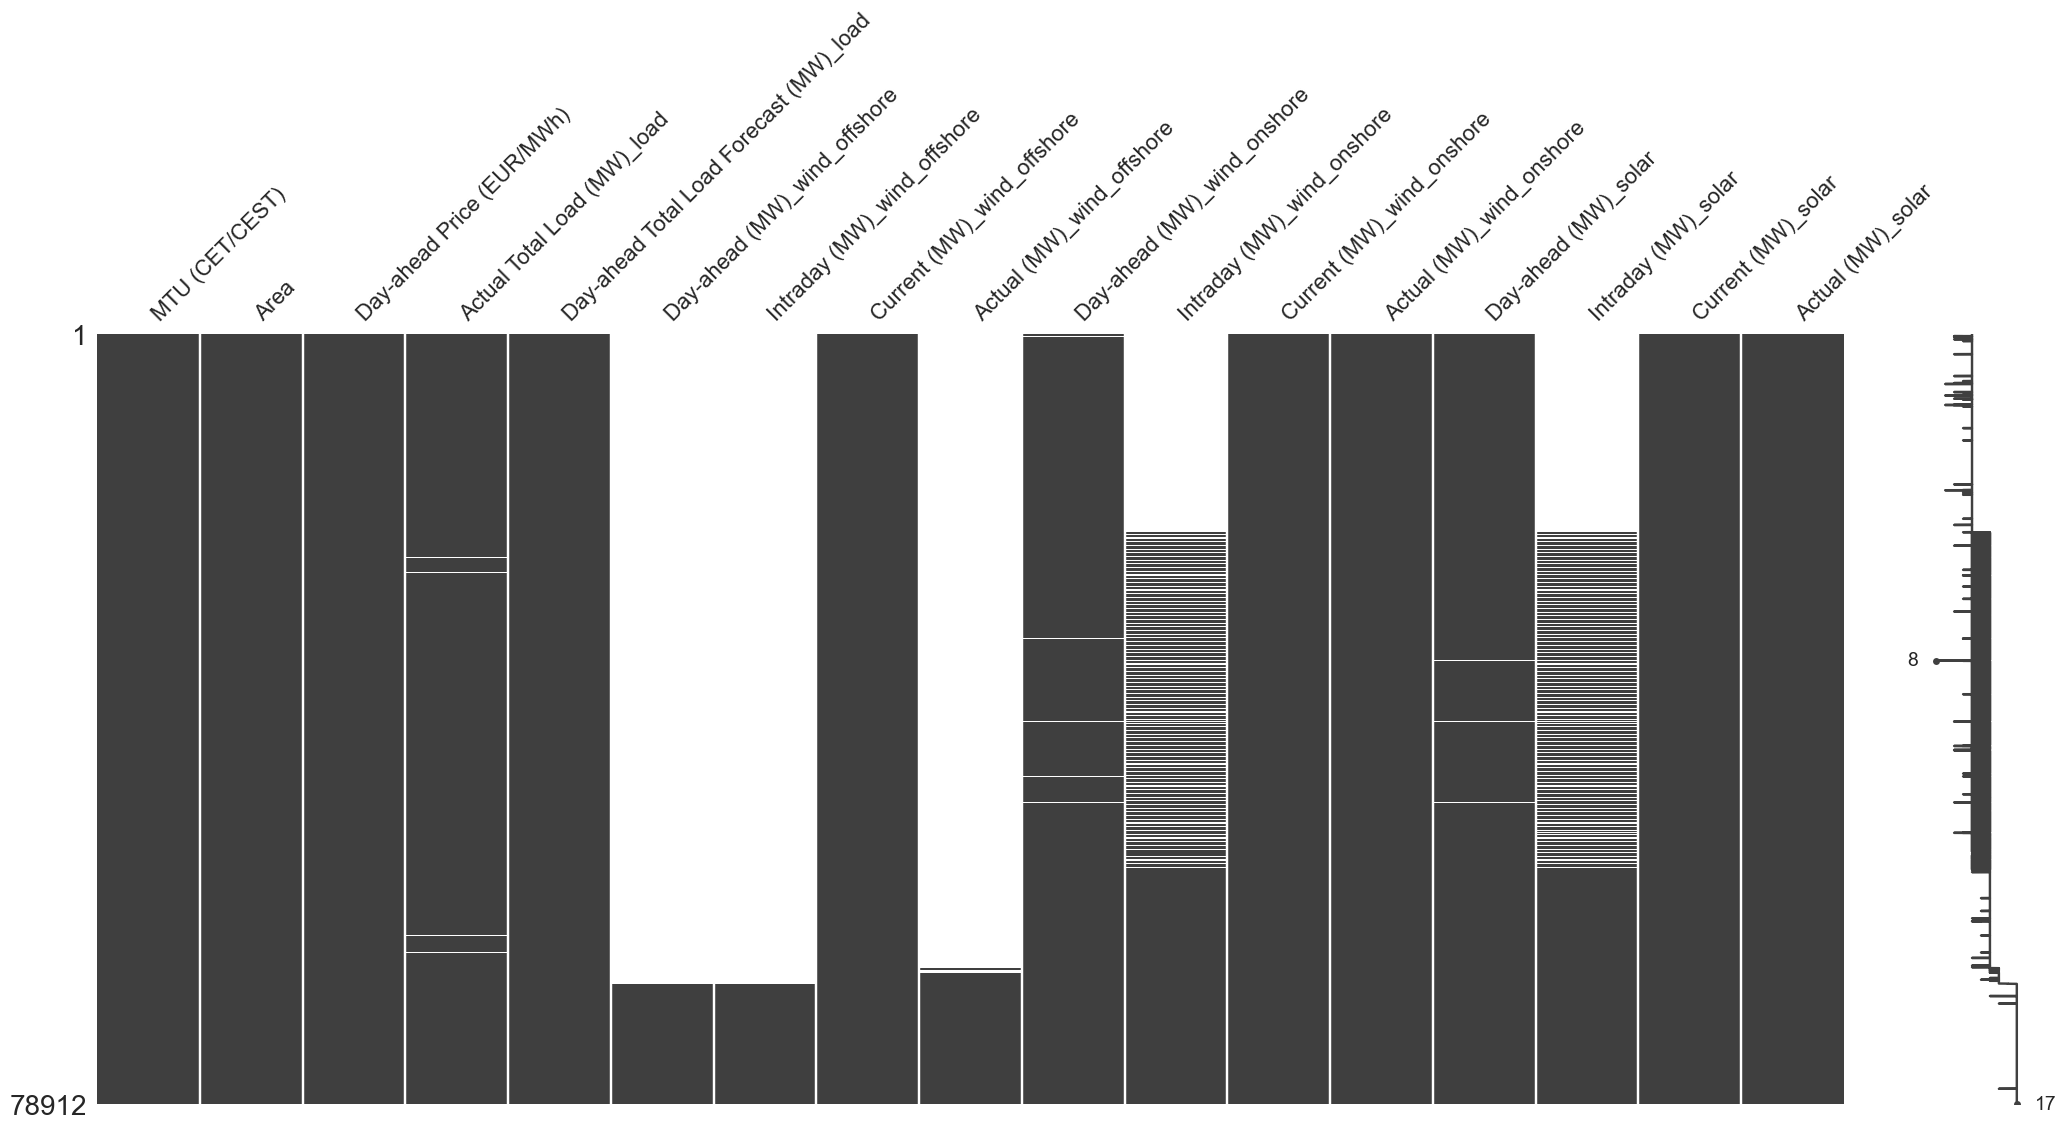

In [22]:
msno.matrix(df_alls_original)

In [23]:
df_alls = df_alls_original.copy()

## Exploratory Data Analysis (EDA)

### Distribution of Prices

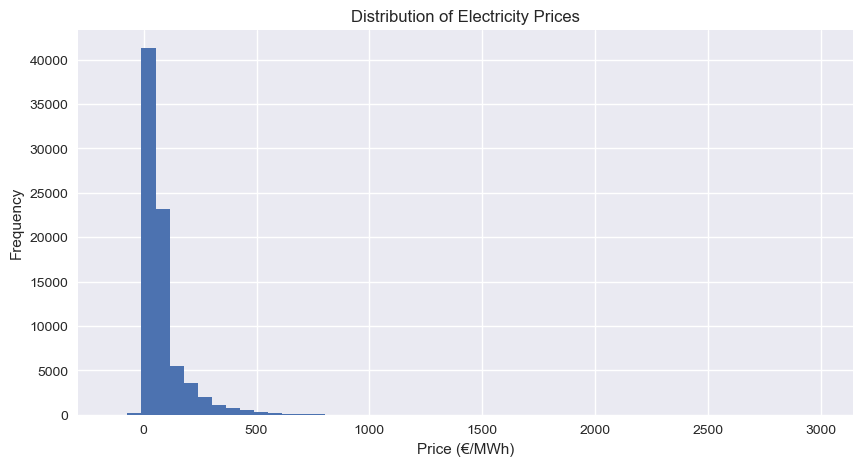

In [24]:
plt.figure(figsize = (10,5))
df_alls["Day-ahead Price (EUR/MWh)"].hist(bins=50)
plt.title("Distribution of Electricity Prices")
plt.xlabel("Price (€/MWh)")
plt.ylabel("Frequency")
plt.show()

**Electricity prices show a right-skewed distribution, indicating occasional extreme price spikes.**

#### Hourly Patterns

In [25]:
hourly_price = df_alls.groupby(df_alls.index.hour)["Day-ahead Price (EUR/MWh)"].agg(
    hourly_mean = "mean"
).reset_index().rename(columns = {"timestamp": "hour"})

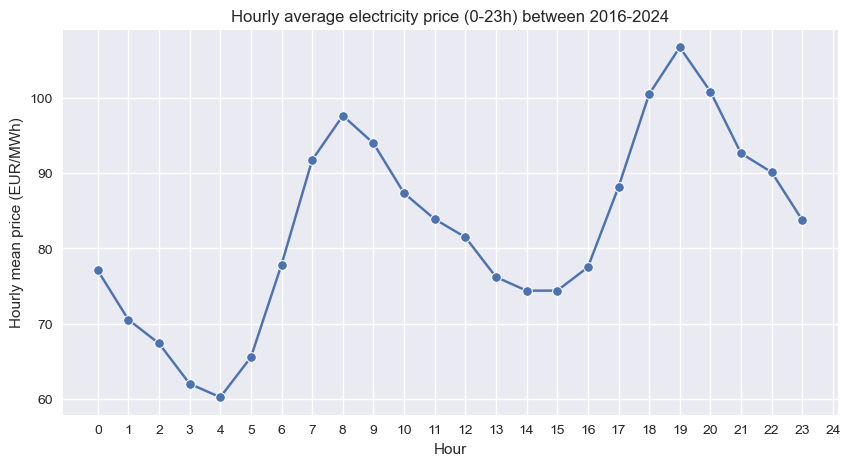

In [26]:
plt.figure(figsize = (10,5))
sns.lineplot(hourly_price, x = "hour", y = "hourly_mean", marker = "o")
plt.xticks(range(0, 25))
plt.xlabel("Hour")
plt.ylabel("Hourly mean price (EUR/MWh)")
plt.title("Hourly average electricity price (0-23h) between 2016-2024")
plt.show()

**Intraday Pattern (Hourly Seasonality)** <br>
- The highest average price occurs at 19:00, representing the primary daily peak.
- The second highest peak occurs at 08:00, corresponding to the morning demand ramp-up. <br>

#### Weekly Patterns

In [27]:
weekday_mean = df_alls.groupby(df_alls.index.weekday)["Day-ahead Price (EUR/MWh)"].agg(
    day_mean = "mean"
).reset_index().rename(columns = {"timestamp": "weekday"})
weekday_mean

,weekday,day_mean
0,0,85.627520
1,1,90.629831
2,2,90.356288
3,3,89.817034
4,4,87.125400
5,5,72.426141
6,6,62.061757


In [28]:
weekday_map = {0: "Monday",
               1: "Tuesday",
               2: "Wednesday",
               3: "Thursday",
               4: "Friday", 
               5: "Saturday",
               6: "Sunday"}

weekday_mean["weekday"] = weekday_mean["weekday"].map(weekday_map)
weekday_mean

,weekday,day_mean
0,Monday,85.627520
1,Tuesday,90.629831
2,Wednesday,90.356288
3,Thursday,89.817034
4,Friday,87.125400
5,Saturday,72.426141
6,Sunday,62.061757


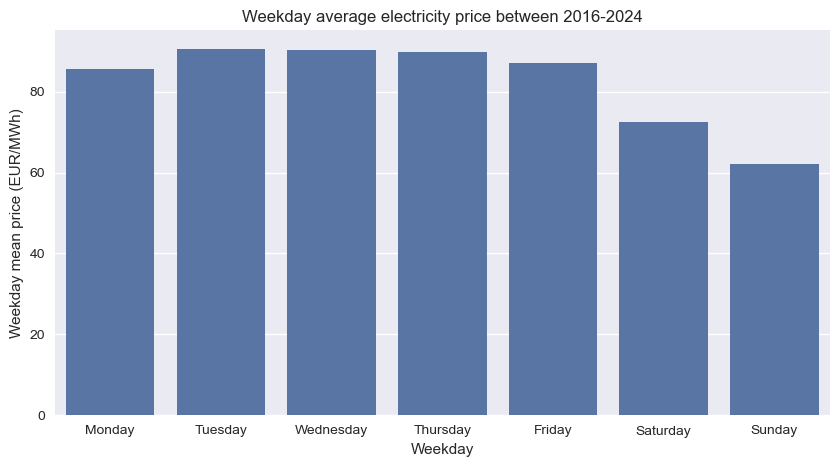

In [29]:
plt.figure(figsize = (10,5))
sns.barplot(data = weekday_mean, x = "weekday", y = "day_mean")
plt.xlabel("Weekday")
plt.ylabel("Weekday mean price (EUR/MWh)")
plt.title("Weekday average electricity price between 2016-2024")
plt.show()

**Prices are generally lower on weekends, reflecting reduced industrial activity.**

#### Seasonal Trends

In [30]:
monthly_mean = df_alls.groupby(df_alls.index.month)["Day-ahead Price (EUR/MWh)"].agg(
    monthly_mean = "mean"
).reset_index().rename(columns = {"timestamp": "month"})
monthly_mean

,month,monthly_mean
0,1,80.590414
1,2,70.701395
2,3,75.494561
3,4,64.020304
4,5,55.824885
5,6,67.653202
6,7,87.905281
7,8,100.608672
8,9,98.825407
9,10,82.730294


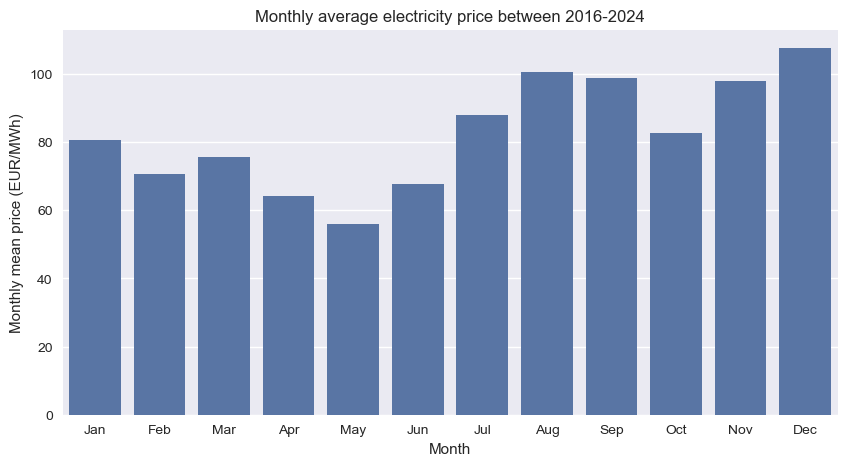

In [31]:
plt.figure(figsize = (10, 5))
sns.barplot(data = monthly_mean, x = "month", y ="monthly_mean")
plt.xlabel("Month")
plt.ylabel("Monthly mean price (EUR/MWh)")
plt.title("Monthly average electricity price between 2016-2024")
plt.xticks(range(0,12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

**Winter months exhibit significantly higher prices (~30–40% higher), likely driven by heating demand and lower solar production.**

#### Yearly Trends

In [32]:
yearly_mean = df_alls.groupby(df_alls.index.year)["Day-ahead Price (EUR/MWh)"].agg(
    yearly_mean = "mean"
).reset_index().rename(columns = {"timestamp": "year"})
yearly_mean

,year,yearly_mean
0,2016,36.748941
1,2017,44.965311
2,2018,50.198485
3,2019,39.449507
4,2020,32.203133
5,2021,109.171356
6,2022,275.878425
7,2023,96.855878
8,2024,58.018068


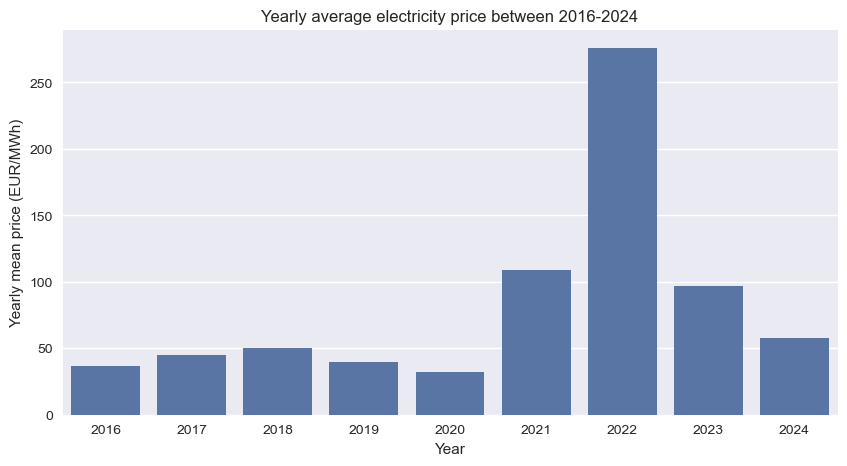

In [33]:
plt.figure(figsize = (10,5))
sns.barplot(yearly_mean, x = "year", y = "yearly_mean")
plt.xlabel("Year")
plt.ylabel("Yearly mean price (EUR/MWh)")
plt.title("Yearly average electricity price between 2016-2024")
plt.show()

A strong structural shift is visible across years:<br>
- 2020 shows a dip in average prices, likely linked to reduced economic activity.
- 2021 marks a strong rebound.
- 2022 exhibits an extreme surge, with average prices more than 2.5× higher than in 2021.
- 2023 returns closer to historical norms.
- 2024 shows a further decline.

The magnitude of the 2022 increase indicates a structural market disruption rather than normal cyclical variation. The normalization in 2023–2024 suggests partial market stabilization.

## Correlation Analysis
### Relationship Between Variables individually
#### Day-ahead Total Load vs Day-ahead Price

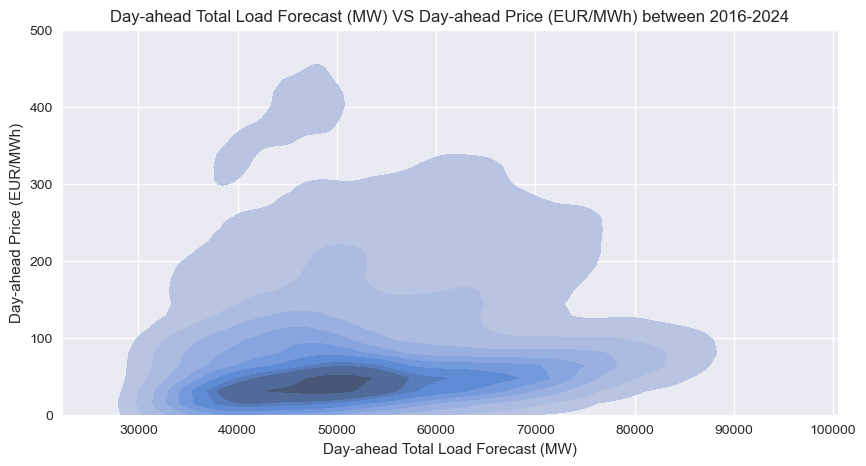

In [34]:
plt.figure(figsize = (10,5))
sns.kdeplot(data = df_alls, x = "Day-ahead Total Load Forecast (MW)_load", y = "Day-ahead Price (EUR/MWh)", fill = True)
plt.ylim(0,500)
plt.xlabel("Day-ahead Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.title('Day-ahead Total Load Forecast (MW) VS Day-ahead Price (EUR/MWh) between 2016-2024')
plt.show()

In [35]:
df_alls[["Day-ahead Price (EUR/MWh)", "Day-ahead Total Load Forecast (MW)_load"]].corr()

,Day-ahead Price (EUR/MWh),Day-ahead Total Load Forecast (MW)_load
Day-ahead Price (EUR/MWh),1.000000,0.109274
Day-ahead Total Load Forecast (MW)_load,0.109274,1.000000


The Pearson correlation between load and electricity price is 0.109, indicating a weak linear relationship across the full sample period.

In [36]:
df_load_bin = df_alls.assign(Forecast_load_bins = pd.qcut(df_alls["Day-ahead Total Load Forecast (MW)_load"], 20)).groupby(
                              "Forecast_load_bins", observed = True).agg(
                              load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
                              price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                              price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                              price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                              price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
                              )
df_load_bin

,load_mean,price_mean,price_std,price_90th,price_99th
Forecast_load_bins,,,,,
"(27649.999, 35850.0]",33796.868952,60.150570,81.269802,117.927,433.8982
"(35850.0, 38250.0]",37150.144602,69.007245,92.483038,163.020,468.9890
"(38250.0, 40100.0]",39230.880401,71.195394,94.402921,162.164,480.0694
"(40100.0, 41750.0]",40970.393905,72.674678,95.482669,160.032,508.2702
"(41750.0, 43350.0]",42589.207041,70.911579,88.014492,139.406,479.2193
"(43350.0, 44900.0]",44162.742024,80.387662,97.558931,171.927,508.0915
"(44900.0, 46300.0]",45629.986216,81.197287,101.137678,165.442,543.0224
"(46300.0, 47650.0]",46995.564792,85.366030,103.742342,184.949,546.3073
"(47650.0, 48950.0]",48316.368168,87.789504,109.700762,190.948,575.5274


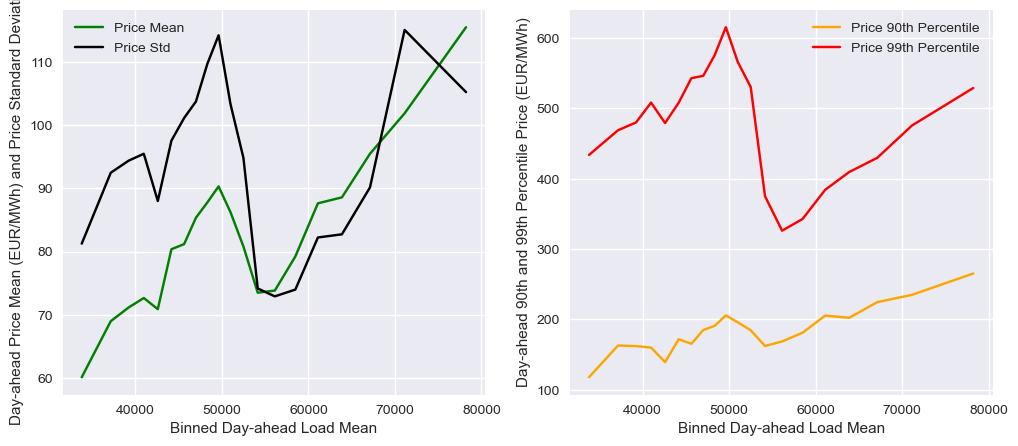

In [37]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Load Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Load Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

After grouping load into 20 quantile-based bins and computing the average price per bin, a clear upward trend emerges: higher load levels are generally associated with higher day-ahead prices.

However, the relationship is not perfectly monotonic. A noticeable dip is observed around ~54,143 MW. This suggests that load alone does not fully explain price behavior. Possible explanations include:
- High renewable penetration during those load conditions,
- Differences in yearly composition (e.g., crisis-year observations),
- State-dependent market dynamics.

#### Day-ahead Wind Load (off-shore) vs Day-ahead Price

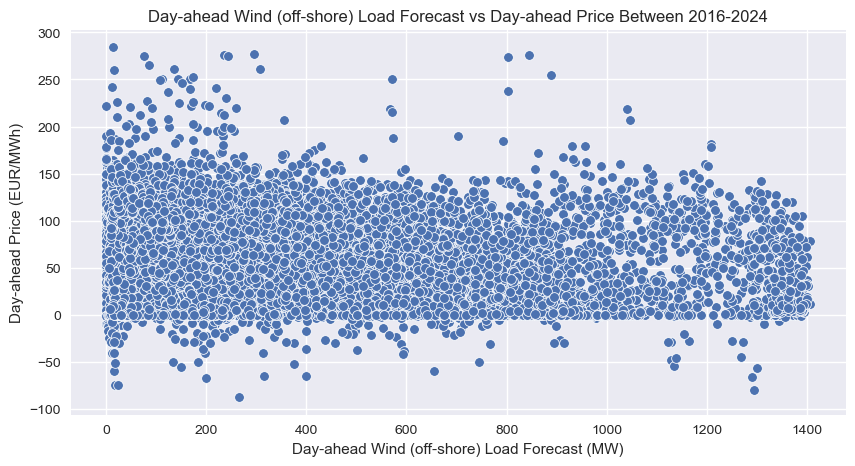

In [39]:
df_alls["Day-ahead (MW)_wind_offshore"] = df_alls["Day-ahead (MW)_wind_offshore"].astype(float)

plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_offshore", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind (off-shore) Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind (off-shore) Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [40]:
df_wind_offshore_load_bins = df_alls.assign(**{"Day-ahead (MW)_wind_offshore_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_offshore"], 20, duplicates= "drop")}
                                            ).groupby(
                                                "Day-ahead (MW)_wind_offshore_bins", observed = True).agg(
                                                 wind_mean = ("Day-ahead (MW)_wind_offshore", "mean"),
                                                 price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                                                 price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                                                 price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                                                 price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_wind_offshore_load_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_offshore_bins,,,,,
"(-0.001, 5.0]",0.815287,87.081401,33.140000,125.663,166.8758
"(5.0, 23.5]",14.554688,82.362582,44.983341,127.874,187.0457
"(23.5, 47.5]",35.475324,79.340324,38.825017,123.475,165.2988
"(47.5, 73.0]",59.901626,80.979935,38.144767,124.744,164.8314
"(73.0, 101.5]",87.403437,79.563290,40.411592,124.640,188.1850
"(101.5, 134.5]",118.016532,68.951371,41.238291,117.933,166.4230
"(134.5, 172.5]",152.531915,70.575041,44.313638,122.000,218.7330
"(172.5, 209.4]",190.361156,69.752541,44.616235,120.983,193.8040
"(209.4, 240.0]",229.457986,56.872319,44.090661,109.124,193.9797


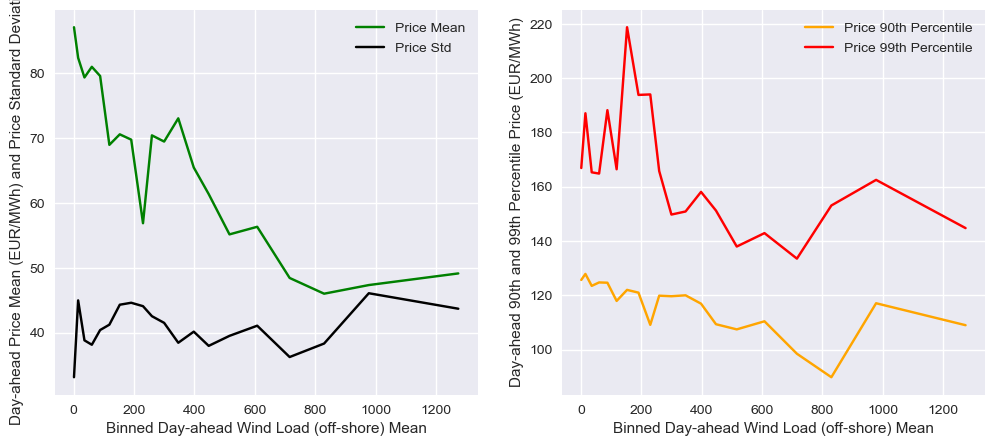

In [41]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Load (off-shore) Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Wind Load (off-shore) Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

Offshore wind demonstrates a price-suppressing effect. 

#### Day-ahead Wind Load (On-shore) vs Day-ahead Price

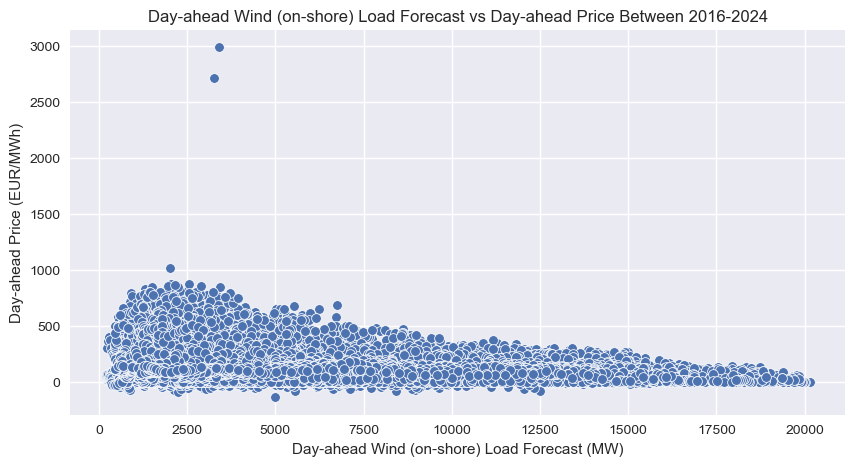

In [42]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_onshore", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind (on-shore) Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind (on-shore) Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [43]:
df_wind_onshore_load_bins = df_alls.assign(**{"Day-ahead (MW)_wind_onshore_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_onshore"], 20)}
    ).groupby("Day-ahead (MW)_wind_onshore_bins", observed = True).agg(
    wind_mean = ("Day-ahead (MW)_wind_onshore", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_wind_onshore_load_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_onshore_bins,,,,,
"(185.089, 823.36]",628.400559,63.032504,67.522991,101.100,387.0700
"(823.36, 1086.614]",961.063042,74.043509,90.440393,138.552,523.8292
"(1086.614, 1299.688]",1199.135026,80.232099,101.796504,167.070,557.3007
"(1299.688, 1494.946]",1397.529362,82.977003,103.444261,189.343,559.7067
"(1494.946, 1700.92]",1597.472119,86.127881,106.615758,205.510,541.4980
"(1700.92, 1906.646]",1804.474982,88.032118,107.244347,211.226,540.8059
"(1906.646, 2119.28]",2012.935541,89.245492,108.808152,218.061,544.9208
"(2119.28, 2346.304]",2231.467931,89.043727,104.740534,211.511,535.4239
"(2346.304, 2589.862]",2467.705426,90.728342,103.853925,210.011,518.2462


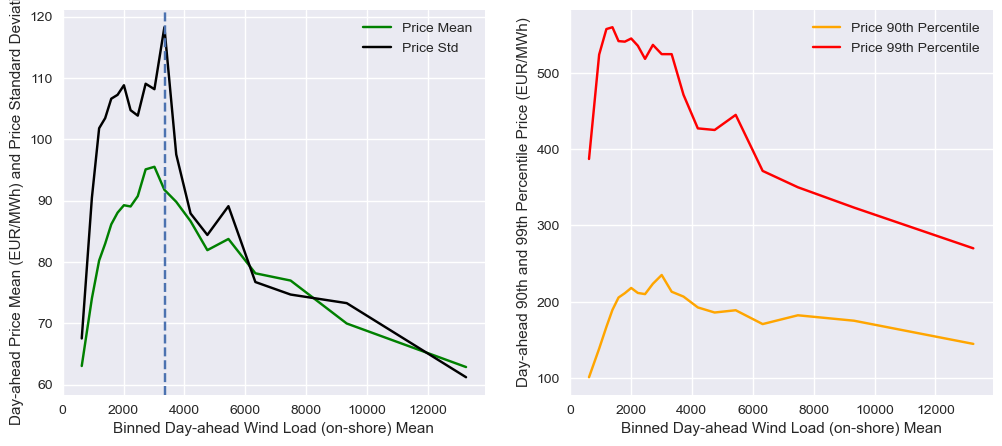

In [44]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Load (on-shore) Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Wind Load (on-shore) Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")
axs[0].axvline(x = 3345, ls = "--")
plt.legend()
plt.show()

The analysis indicates a nonlinear relationship between onshore wind output and day-ahead price levels. 

In low-output regimes, price levels and volatility remain elevated, with pronounced upper-tail risk (P99). 

As onshore wind increases beyond ~3,3 GW, both average prices and tail dispersion compress, suggesting displacement of higher-cost marginal units. 

However, onshore wind alone does not fully determine the marginal cost regime, as other renewable sources and demand dynamics may simultaneously influence price formation.

#### Day-ahead Total Wind Load vs Day-ahead Price

In [45]:
df_alls["Day-ahead (MW)_wind_total"] = df_alls["Day-ahead (MW)_wind_offshore"] + df_alls["Day-ahead (MW)_wind_onshore"]

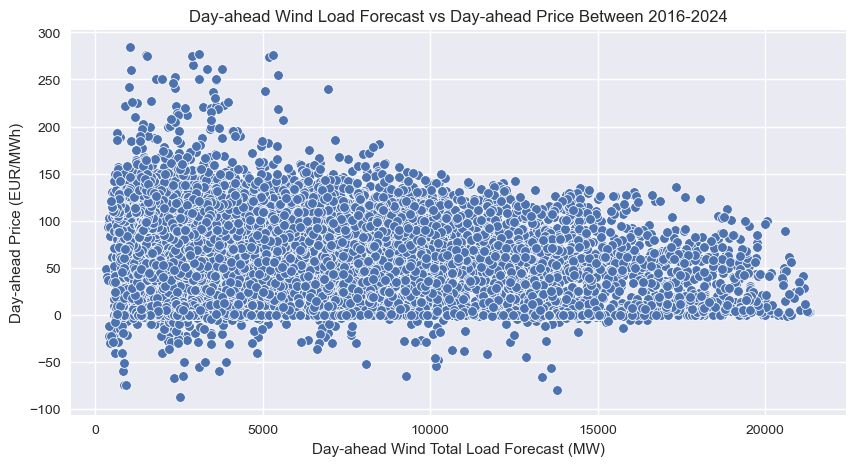

In [46]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_total", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [49]:
df_day_ahead_wind_total_bins = df_alls.assign(
    **{"Day-ahead (MW)_wind_total_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 20)}
).groupby("Day-ahead (MW)_wind_total_bins",
                                               observed = True).agg(
                                                wind_mean = ("Day-ahead (MW)_wind_total", "mean"),
                                                price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                                                price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                                                price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                                                price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_day_ahead_wind_total_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_total_bins,,,,,
"(313.78900000000004, 1215.32]",904.483782,70.019253,47.776107,123.665,192.4030
"(1215.32, 1589.96]",1402.636786,80.945000,42.722437,128.150,189.3440
"(1589.96, 1914.35]",1759.093057,81.807122,38.747433,125.206,164.0086
"(1914.35, 2243.4]",2084.674042,70.364221,42.513011,120.625,171.3065
"(2243.4, 2547.93]",2391.311951,74.610732,46.395121,126.454,207.9552
"(2547.93, 2860.05]",2703.783052,72.431201,40.672072,121.745,160.3325
"(2860.05, 3209.36]",3030.093789,70.544650,43.559330,122.992,179.8686
"(3209.36, 3555.08]",3376.681899,71.074627,40.942829,116.415,193.0035
"(3555.08, 4007.74]",3775.540341,72.369285,44.610650,123.680,221.7044


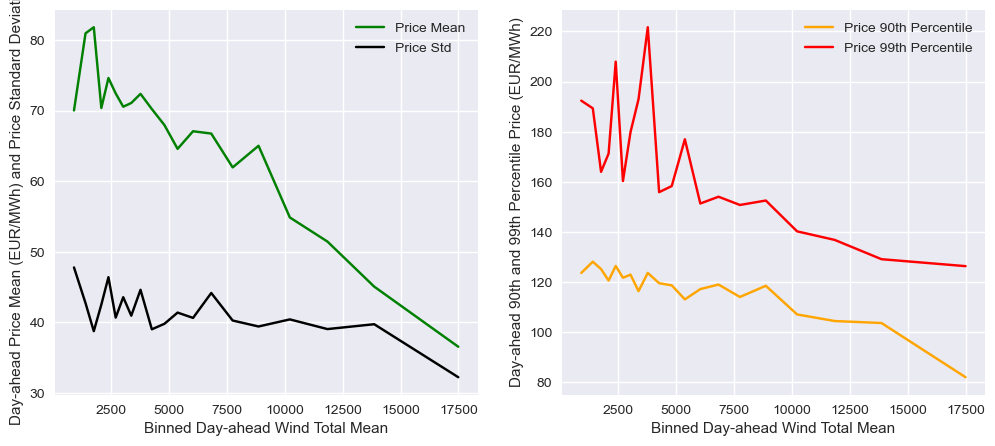

In [50]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Total Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Wind Total Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

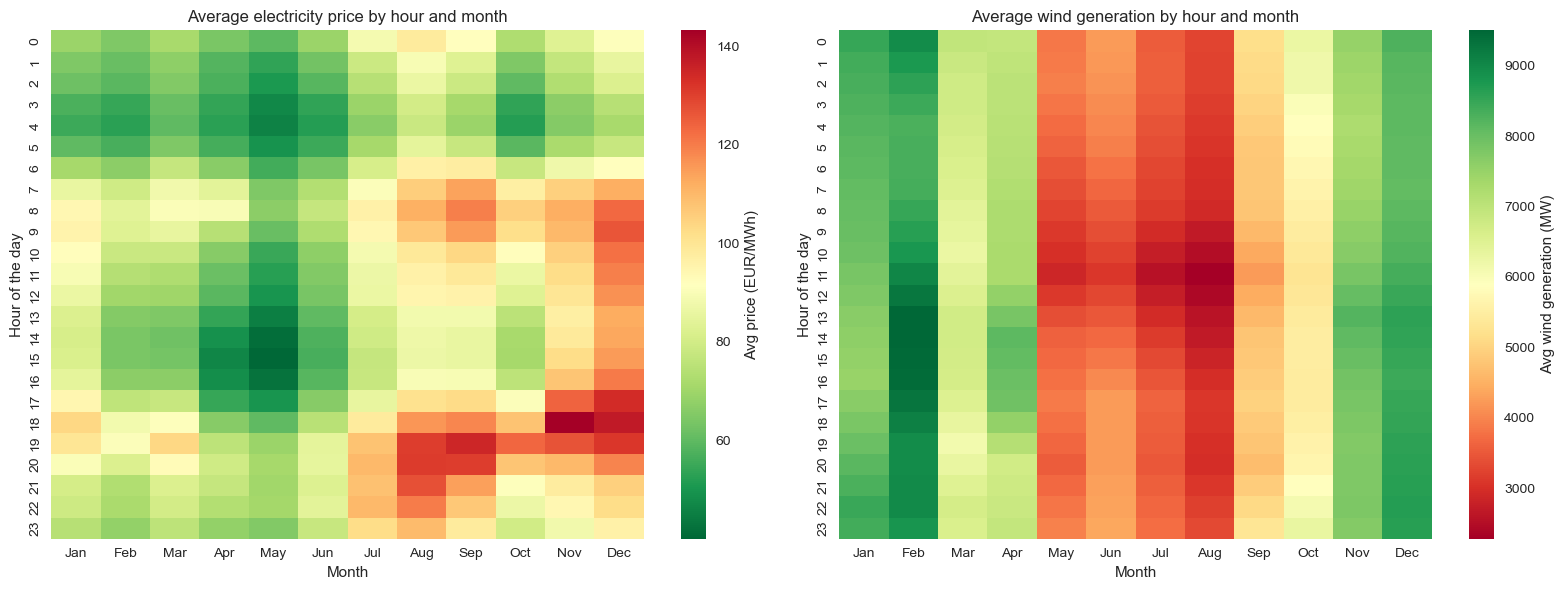

In [51]:
fig, axes = plt.subplots(1,2, figsize = (16, 6))

price_hourly_monthly = df_alls.groupby(
    [df_alls.index.month, df_alls.index.hour]
)["Day-ahead Price (EUR/MWh)"].mean().unstack(level = 0)

price_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(price_hourly_monthly, ax = axes[0], cmap = "RdYlGn_r", 
            cbar_kws = {"label": "Avg price (EUR/MWh)"})
axes[0].set_title("Average electricity price by hour and month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Hour of the day")

wind_hourly_monthly = df_alls.groupby(
    [df_alls.index.month, df_alls.index.hour]
)["Day-ahead (MW)_wind_total"].mean().unstack(level = 0)
wind_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(wind_hourly_monthly, ax = axes[1], cmap = "RdYlGn",
            cbar_kws = {"label": "Avg wind generation (MW)"})
axes[1].set_title("Average wind generation by hour and month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Hour of the day")

plt.tight_layout()
plt.show()

#### Day-ahead Solar Load vs Day-ahead Price

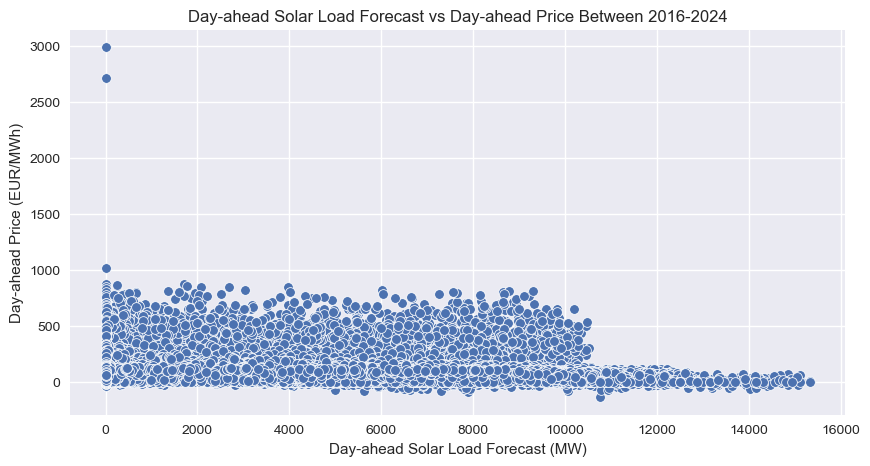

In [52]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_solar", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Solar Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Solar Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [53]:
df_solar_day_ahead_nonzero = df_alls[df_alls["Day-ahead (MW)_solar"] > 0].copy()

In [54]:
df_solar_load_bins = df_solar_day_ahead_nonzero.assign(
    **{"Day-ahead (MW)_solar_bins" : pd.qcut(df_alls["Day-ahead (MW)_solar"], 20, duplicates = "drop")}
).groupby("Day-ahead (MW)_solar_bins", observed = True).agg(
                                                            solar_mean = ("Day-ahead (MW)_solar", "mean"),
                                                            price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                                                            price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                                                            price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                                                            price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_solar_load_bins

,solar_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_solar_bins,,,,,
"(-0.001, 16.415]",3.616200,88.028786,99.089696,189.092,537.2476
"(16.415, 253.496]",114.217256,90.865490,99.468477,207.046,521.5330
"(253.496, 782.218]",498.642787,88.112841,98.477419,195.357,523.3579
"(782.218, 1450.765]",1114.318895,83.452823,95.224770,169.470,519.6891
"(1450.765, 2100.655]",1774.691863,80.491184,91.102307,164.018,487.9616
"(2100.655, 2736.868]",2416.829239,71.886598,79.754187,139.769,450.5980
"(2736.868, 3418.12]",3081.955059,73.388818,88.846780,169.007,475.3673
"(3418.12, 4172.883]",3788.949176,73.394170,89.625137,172.914,470.4316
"(4172.883, 5253.201]",4664.137144,81.748678,94.924068,193.632,481.5492


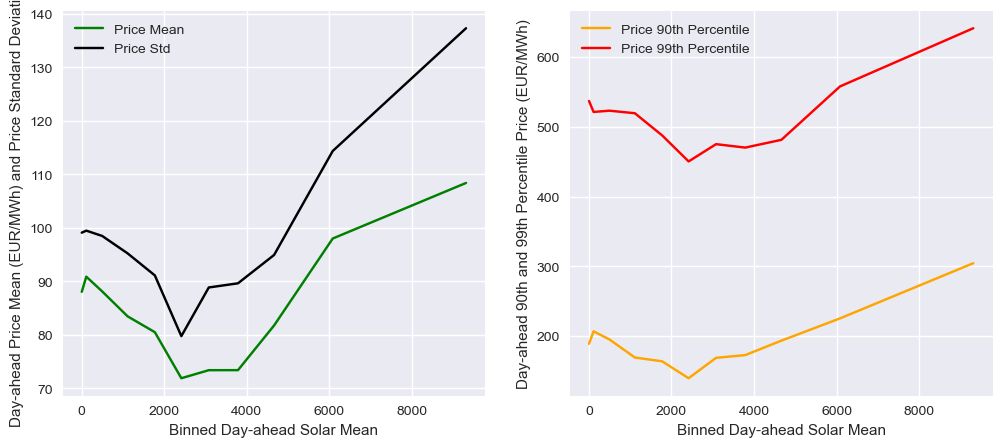

In [55]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Solar Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Solar Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

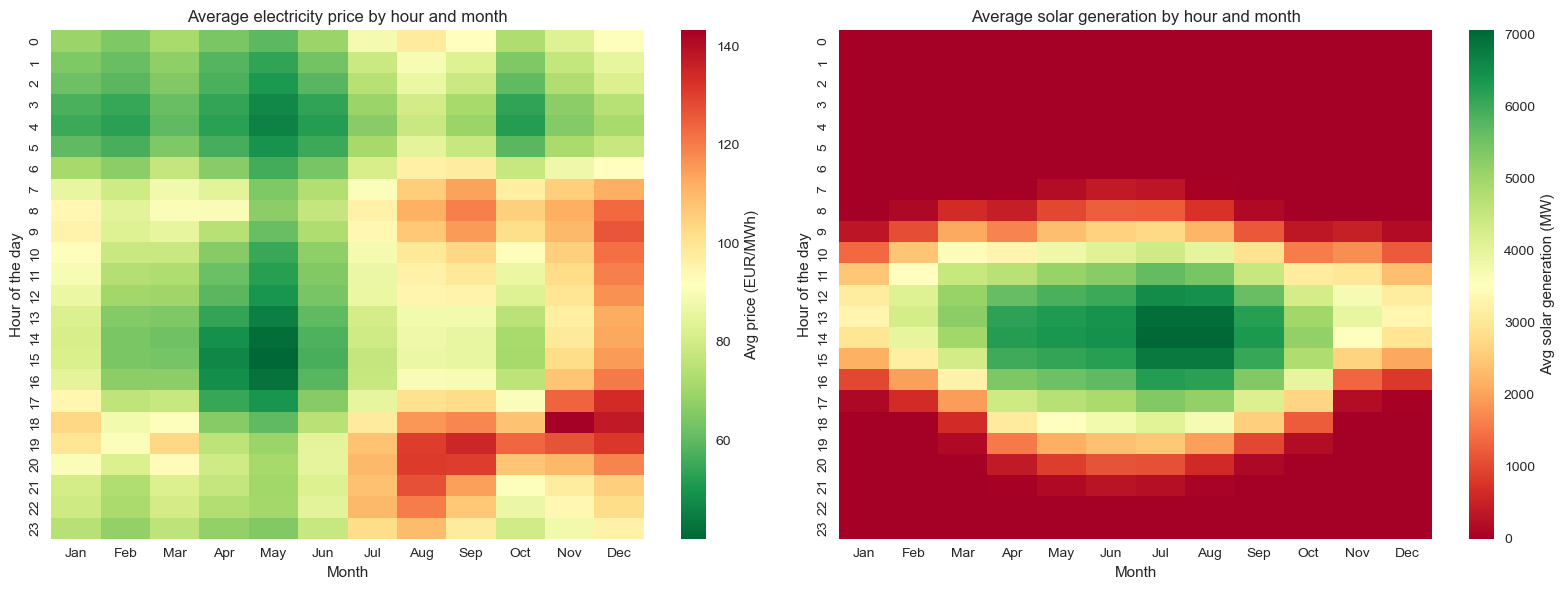

In [56]:
fig, axes = plt.subplots(1,2, figsize = (16, 6))

sns.heatmap(price_hourly_monthly, ax = axes[0], cmap = "RdYlGn_r", 
            cbar_kws = {"label": "Avg price (EUR/MWh)"})
axes[0].set_title("Average electricity price by hour and month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Hour of the day")

solar_hourly_monthly = df_alls.groupby(
    [df_alls.index.month, df_alls.index.hour]
)["Day-ahead (MW)_solar"].mean().unstack(level = 0)
solar_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(solar_hourly_monthly, ax = axes[1], cmap = "RdYlGn",
            cbar_kws = {"label": "Avg solar generation (MW)"})
axes[1].set_title("Average solar generation by hour and month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Hour of the day")

plt.tight_layout()
plt.show()



The relationship between renewable generation and day-ahead price exhibits heterogeneous behavior across technologies.

#### Day-ahead Net Load & Day-ahead Total Load vs Day-ahead Price

In [57]:
df_alls["net_load"] = df_alls["Day-ahead Total Load Forecast (MW)_load"] - (df_alls["Day-ahead (MW)_wind_offshore"] 
                                                                            + df_alls["Day-ahead (MW)_wind_onshore"]
                                                                            + df_alls["Day-ahead (MW)_solar"])

In [58]:
df_net_load_bins = df_alls.assign(
    net_load_bins = pd.qcut(df_alls["net_load"], 20)
).groupby("net_load_bins", observed = True).agg(
    net_load_mean = ("net_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)

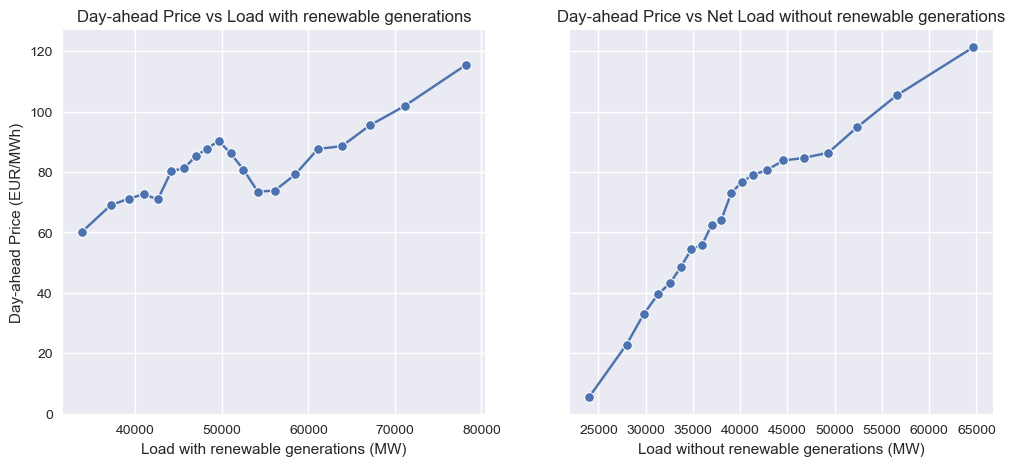

In [59]:
fig, axs = plt.subplots(ncols = 2, figsize = [12, 5], sharey= True)
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_mean", marker = "o", ax = axs[0])
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_mean", marker = "o", ax = axs[1])
axs[0].set_xlabel("Load with renewable generations (MW)")
axs[0].set_ylabel("Day-ahead Price (EUR/MWh)")

axs[0].set_title("Day-ahead Price vs Load with renewable generations")

axs[1].set_xlabel("Load without renewable generations (MW)")
axs[1].set_ylabel("Day-ahead Price (EUR/MWh)")
axs[1].set_title("Day-ahead Price vs Net Load without renewable generations")
plt.show()

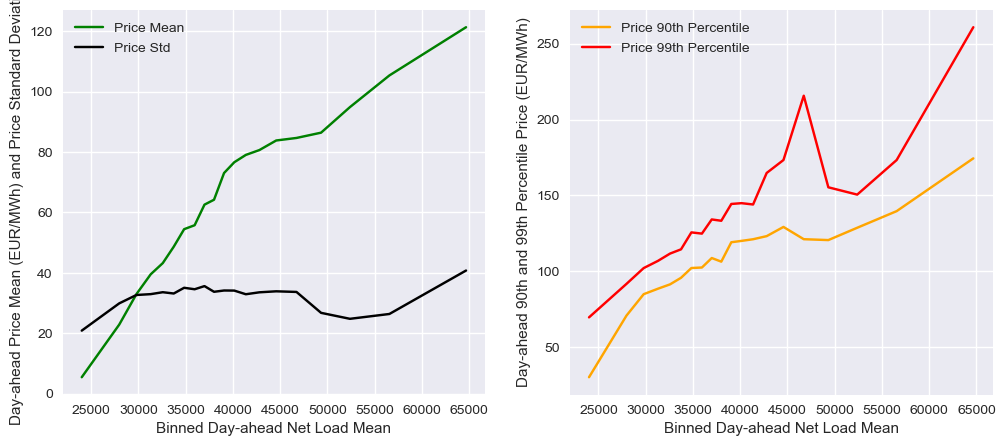

In [60]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Net Load Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Net Load Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

### Residual Load Duration Curve (RLDC)

In [61]:
net_load_sorted = df_alls["net_load"].sort_values(ascending = False).reset_index(drop = True)
len(net_load_sorted)

78912

In [62]:
net_load_sorted.isna().mean()

np.float64(0.8439907745336578)

In [63]:
net_load_sorted.dropna(inplace = True)

In [64]:
net_load_sorted.count()

np.int64(12311)

In [65]:
x = net_load_sorted.index / len(net_load_sorted)

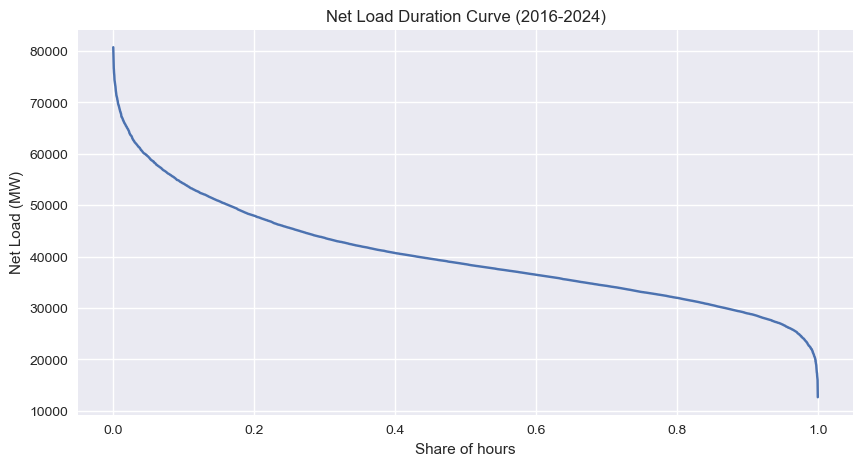

In [66]:
plt.figure(figsize = (10, 5))
plt.plot(x, net_load_sorted)
plt.xlabel("Share of hours")
plt.ylabel("Net Load (MW)")
plt.title("Net Load Duration Curve (2016-2024)")
plt.show()

In [67]:
pivot = df_alls.pivot_table(
    values = "Day-ahead Price (EUR/MWh)",
    index = df_alls.index.hour,
    columns = pd.qcut(df_alls["net_load"], 20),
    aggfunc = "mean",
    observed = False
)

In [68]:
pivot.head()

net_load,"(12648.599, 26789.87]","(26789.87, 28955.37]","(28955.37, 30576.695]","(30576.695, 31980.0]","(31980.0, 33119.64]","(33119.64, 34318.51]","(34318.51, 35365.535]","(35365.535, 36476.63]","(36476.63, 37483.425]","(37483.425, 38528.93]","(38528.93, 39585.54]","(39585.54, 40702.34]","(40702.34, 42055.285]","(42055.285, 43644.37]","(43644.37, 45599.615]","(45599.615, 47942.69]","(47942.69, 50814.435]","(50814.435, 54201.48]","(54201.48, 59403.455]","(59403.455, 80737.0]"
timestamp,,,,,,,,,,,,,,,,,,,,
0,9.070000,24.865000,16.190000,33.534444,43.823529,40.575294,54.996585,64.684200,55.169773,62.024634,67.220217,69.064242,76.584091,70.611071,73.847143,70.601613,71.446207,85.026000,88.701579,96.217059
1,10.039167,21.838889,31.485652,35.297941,52.175102,54.204583,48.982273,55.554902,66.505926,60.373030,64.503333,55.372308,68.772727,64.721818,66.562609,63.950000,74.802174,84.531765,92.702353,83.427273
2,6.448750,26.046316,28.599091,51.919636,41.017917,48.575273,53.227949,54.820286,60.540000,51.684000,65.140769,54.813333,64.147391,67.176667,57.874348,65.175926,73.738947,79.124375,93.638000,81.652727
3,9.868710,28.533793,39.369324,39.061132,46.248043,50.799211,56.096000,53.388667,47.058462,45.297500,56.811200,65.218000,56.852778,58.468000,54.947500,71.720000,72.931250,82.323846,92.203750,76.876667
4,11.565800,30.400460,31.592537,43.949444,45.310769,54.119333,53.954000,41.951667,36.116364,59.134762,62.411429,59.390588,50.548824,62.447692,63.890000,68.868000,75.982143,89.632000,84.577143,73.632857


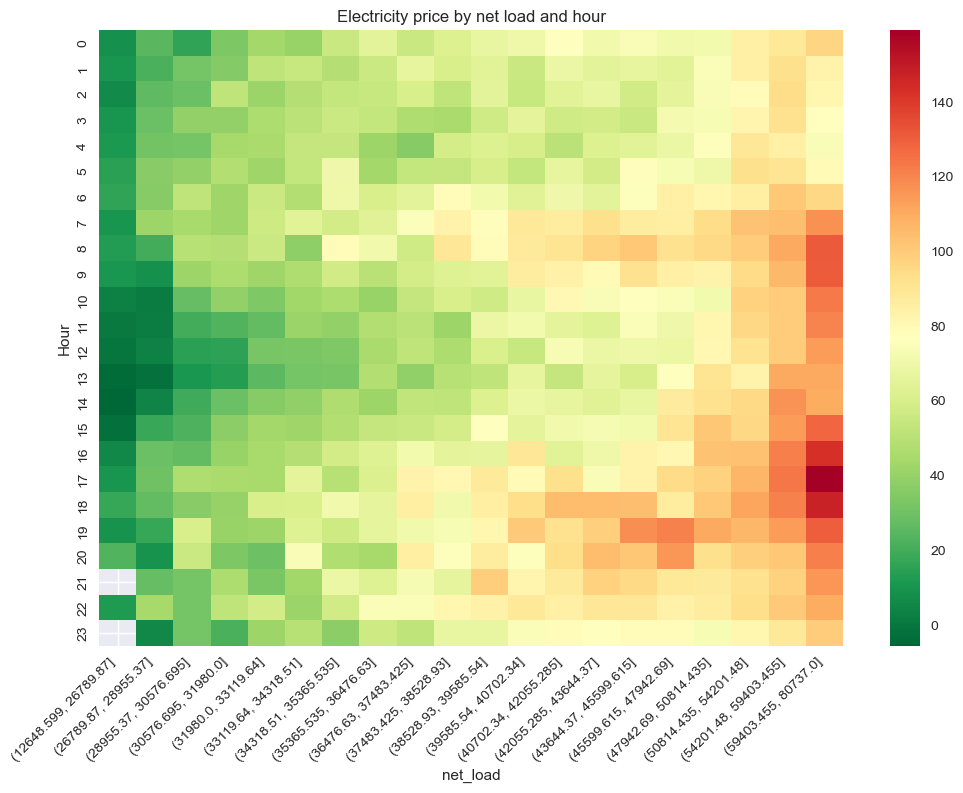

In [69]:
fig, ax = plt.subplots(figsize = (12,8))
ax = sns.heatmap(pivot, cmap = "RdYlGn_r", annot = False)
plt.xticks(rotation = 45, ha = "right")
plt.title("Electricity price by net load and hour")
plt.ylabel("Hour")
plt.show()

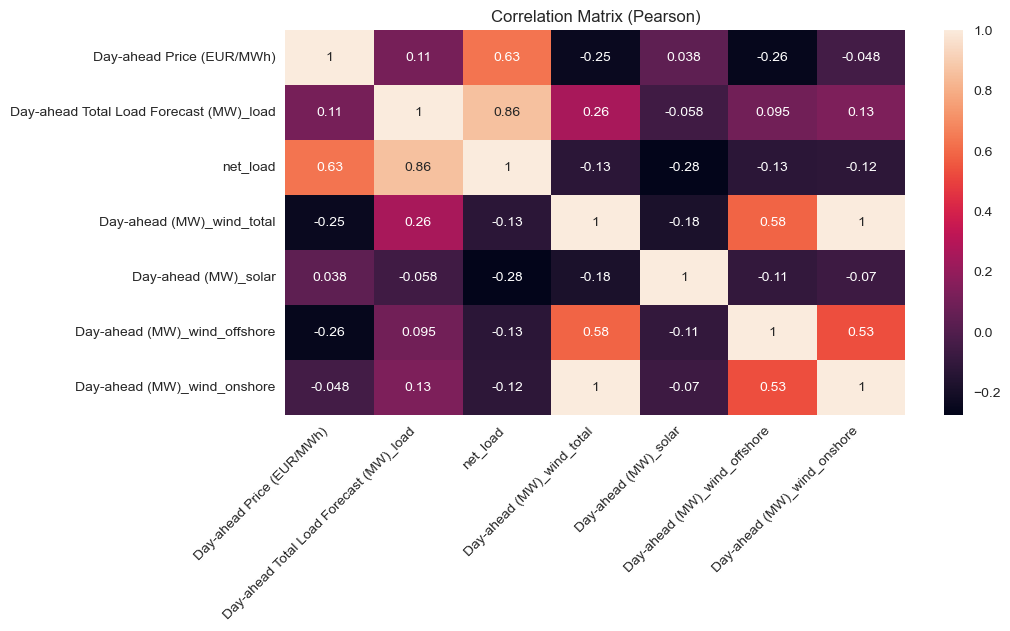

In [70]:
corr_pearson = df_alls[(["Day-ahead Price (EUR/MWh)", "Day-ahead Total Load Forecast (MW)_load", "net_load", "Day-ahead (MW)_wind_total", 
                 "Day-ahead (MW)_solar", "Day-ahead (MW)_wind_offshore", "Day-ahead (MW)_wind_onshore"])].corr(method = "pearson")
plt.figure(figsize = (10, 5))
sns.heatmap(corr_pearson, annot=True)
plt.title("Correlation Matrix (Pearson)")
plt.xticks(rotation = 45, ha = "right")
plt.show()

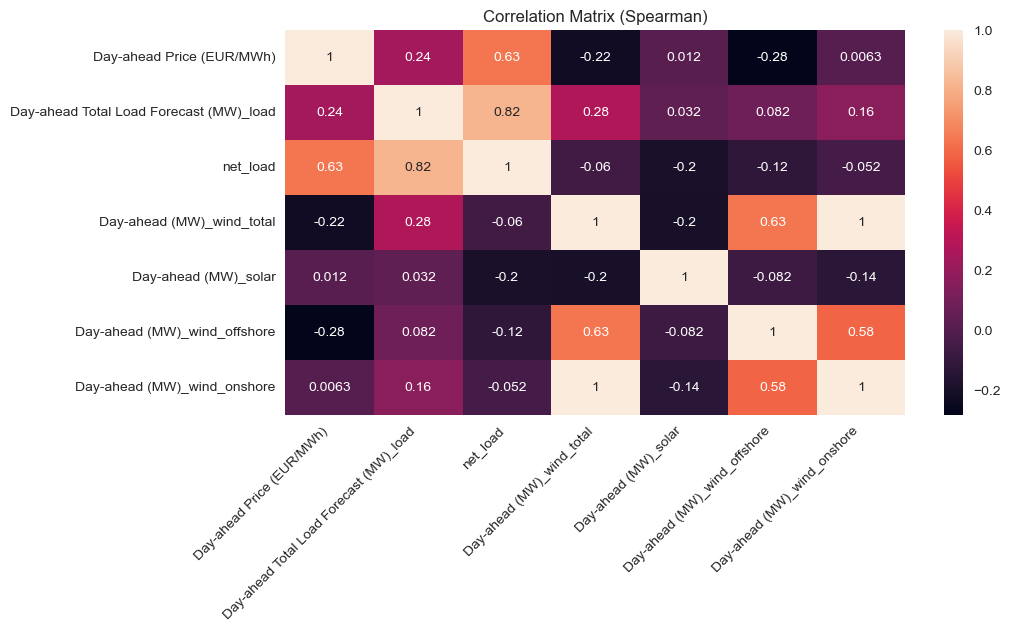

In [71]:
corr_spearman = df_alls[(["Day-ahead Price (EUR/MWh)", "Day-ahead Total Load Forecast (MW)_load", "net_load", "Day-ahead (MW)_wind_total", 
                "Day-ahead (MW)_solar", "Day-ahead (MW)_wind_offshore", "Day-ahead (MW)_wind_onshore"])].corr(method = "spearman")
plt.figure(figsize = (10, 5))
sns.heatmap(corr_spearman, annot=True)
plt.title("Correlation Matrix (Spearman)")
plt.xticks(rotation = 45, ha = "right")
plt.show()

Spearman correlation shows stronger relationships between the net load and price which confirms the non-linear price formation. 

### Joint interaction of variables influence day-ahead price

#### Impact of Load and Wind Load to Prices

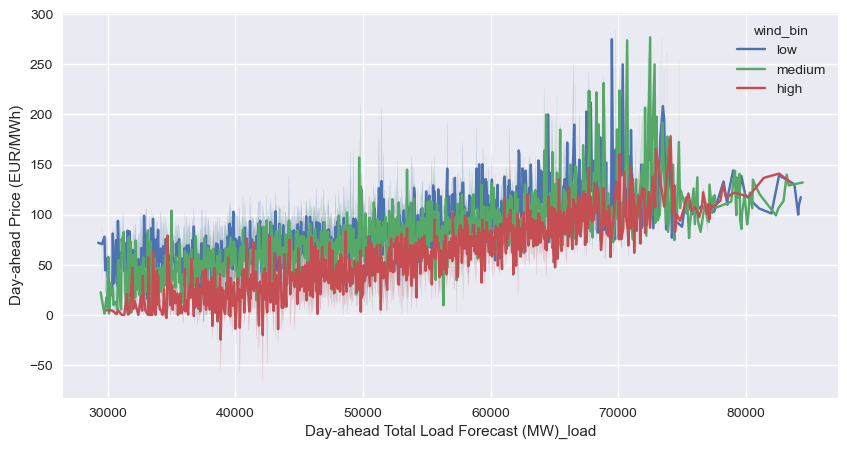

In [72]:
df_alls["wind_bin"] = pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 3, labels=["low", "medium", "high"])
plt.figure(figsize = (10, 5))
sns.lineplot(
    data = df_alls,
    x = "Day-ahead Total Load Forecast (MW)_load",
    y= "Day-ahead Price (EUR/MWh)",
    hue = "wind_bin"
)

plt.show()

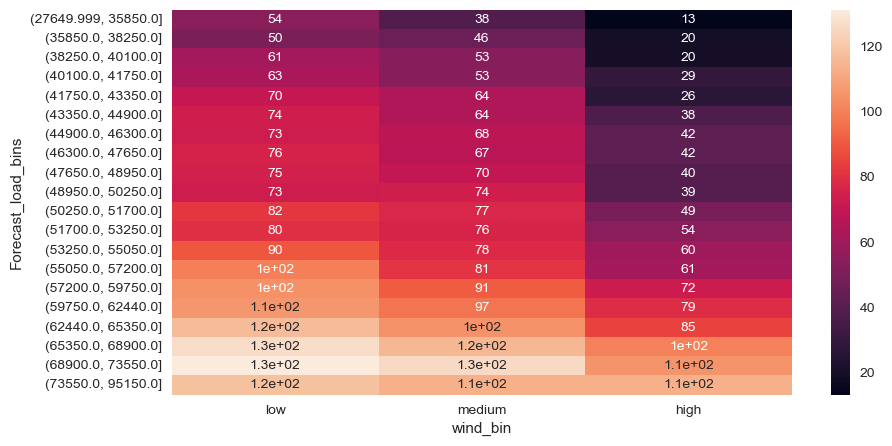

In [73]:
pivot_wind_load_price = df_alls.pivot_table(
    values = "Day-ahead Price (EUR/MWh)",
    index = df_alls.assign(Forecast_load_bins = pd.qcut(df_alls["Day-ahead Total Load Forecast (MW)_load"], 20))["Forecast_load_bins"],
    columns = "wind_bin",
    aggfunc = "mean",
    observed = False
)
plt.figure(figsize = (10, 5))
sns.heatmap(pivot_wind_load_price, annot=True)
plt.show()

#### Impact of Load and Solar Load to Prices

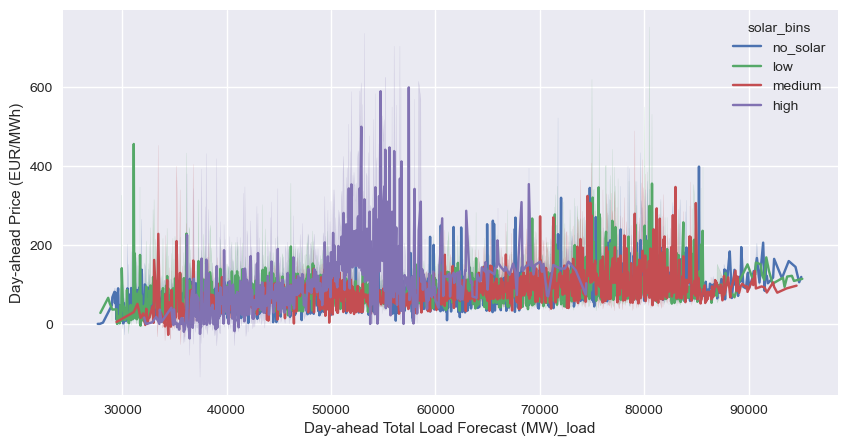

In [74]:
max_solar = df_alls["Day-ahead (MW)_solar"].max()

df_alls["solar_bins"] = pd.cut(
    df_alls["Day-ahead (MW)_solar"],
    bins=[-1, 1, 0.1*max_solar, 0.5*max_solar, max_solar],
    labels=["no_solar", "low", "medium", "high"]
)
plt.figure(figsize = (10, 5))
sns.lineplot(
    data=df_alls,
    x="Day-ahead Total Load Forecast (MW)_load",
    y="Day-ahead Price (EUR/MWh)",
    hue="solar_bins"
)

plt.show()

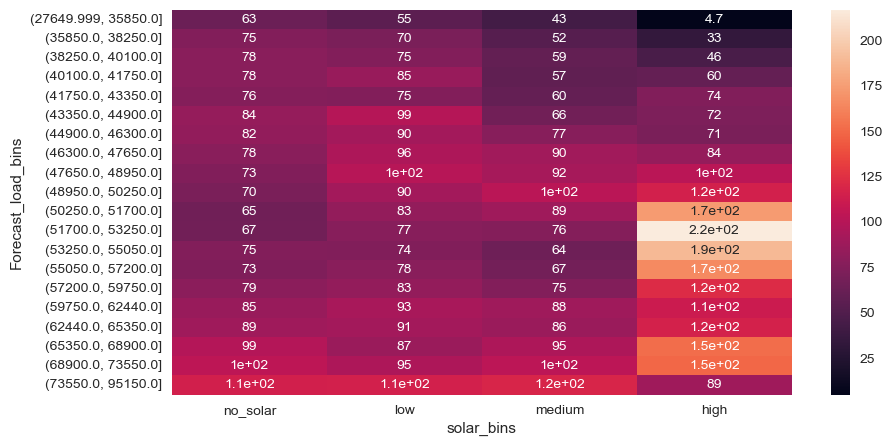

In [75]:
pivot_solar_load_price = df_alls.pivot_table(
    values="Day-ahead Price (EUR/MWh)",
    index = df_alls.assign(Forecast_load_bins = pd.qcut(df_alls["Day-ahead Total Load Forecast (MW)_load"], 20))["Forecast_load_bins"],
    columns = "solar_bins",
    aggfunc="mean",
    observed = False
)
plt.figure(figsize =(10, 5))
sns.heatmap(pivot_solar_load_price, annot=True)
plt.show()

While each renewable component exerts a measurable price impact individually, the marginal unit in the day-ahead market is ultimately determined by aggregate zero-marginal-cost supply. 

## Time Regime Analysis

Split the data set into 3 time periods: 2016-2020 (Pre-crisis baseline), 2021-2022 (Crisis onset and peak), 2023-2024 (Normalization). 

In [76]:
df_2016_2020 = df_alls[(df_alls.index.year >= 2016) & (df_alls.index.year <= 2020)].copy()
df_2021_2022 = df_alls[(df_alls.index.year >= 2021) & (df_alls.index.year <= 2022)].copy()
df_2023_2024 = df_alls[(df_alls.index.year >= 2023) & (df_alls.index.year <= 2024)].copy()

In [77]:
df_2016_2020["price_smooth"] = df_2016_2020["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
df_2021_2022["price_smooth"] = df_2021_2022["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
df_2023_2024["price_smooth"] = df_2023_2024["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()

In [78]:
df_2016_2020["total_load_bins"] = pd.qcut(df_2016_2020["Day-ahead Total Load Forecast (MW)_load"], 20)
df_2021_2022["total_load_bins"] = pd.qcut(df_2021_2022["Day-ahead Total Load Forecast (MW)_load"], 20)
df_2023_2024["total_load_bins"] = pd.qcut(df_2023_2024["Day-ahead Total Load Forecast (MW)_load"], 20)

In [79]:
df_2016_2020_load_bins = df_2016_2020.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2016_2020_load_bins.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(29049.999, 36600.0]",34468.184675,23.078237,12.491590,39.359,51.7367
"(36600.0, 39050.0]",37920.703594,26.774873,12.458340,44.448,57.7918
"(39050.0, 40950.0]",40041.672026,29.112843,12.971111,46.128,64.9496
"(40950.0, 42650.0]",41817.321688,31.421388,13.181690,47.601,69.7508
"(42650.0, 44400.0]",43529.737642,32.883941,13.485360,49.602,70.6904


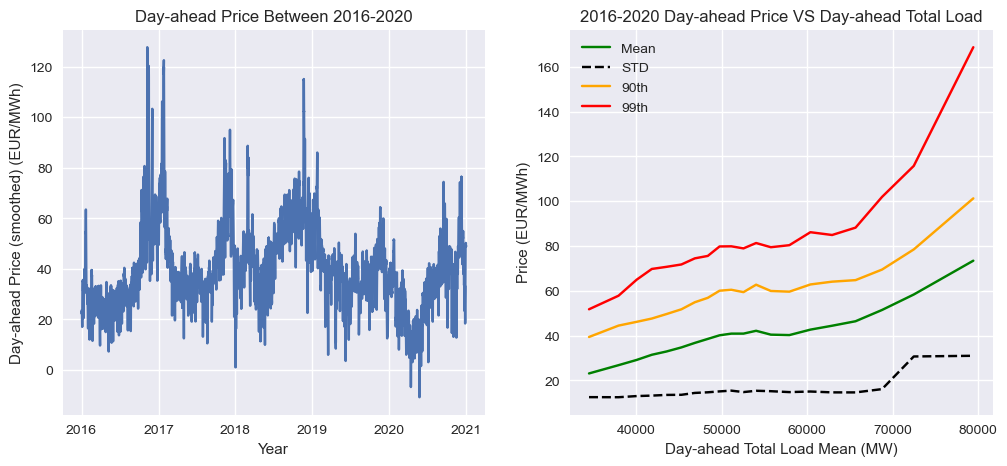

In [80]:
fig, axs = plt.subplots(ncols = 2, figsize = [12, 5])
sns.lineplot(data = df_2016_2020, x = df_2016_2020.index, y = "price_smooth", ax = axs[0])
sns.lineplot(data = df_2016_2020_load_bins, x = "total_load_mean", y = "price_mean", ax = axs[1], label = "Mean", color = "green")
sns.lineplot(data = df_2016_2020_load_bins, x = "total_load_mean", y = "price_std", ax = axs[1], label = "STD", ls = "--", color = "black")
sns.lineplot(data = df_2016_2020_load_bins, x = "total_load_mean", y = "price_90th", ax = axs[1], label = "90th", color = "orange")
sns.lineplot(data = df_2016_2020_load_bins, x = "total_load_mean", y = "price_99th", ax = axs[1], label = "99th", color = "red")
axs[0].set_ylabel("Day-ahead Price (smoothed) (EUR/MWh)")
axs[0].set_xlabel("Year")
axs[0].set_title("Day-ahead Price Between 2016-2020")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[1].set_xlabel("Day-ahead Total Load Mean (MW)")
axs[1].set_title("2016-2020 Day-ahead Price VS Day-ahead Total Load")
plt.show()

In [81]:
df_2021_2022_load_bins = df_2021_2022.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.quantile(x, 0.90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.quantile(x, 0.99))
)
df_2021_2022_load_bins.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(29649.999, 36050.0]",34009.920635,161.755964,131.388325,369.200,539.5458
"(36050.0, 38250.0]",37185.388128,176.010514,134.433072,379.110,571.0650
"(38250.0, 40100.0]",39260.388889,178.908733,142.993972,395.410,599.9624
"(40100.0, 41600.0]",40891.345029,179.799825,144.877735,401.480,667.9400
"(41600.0, 43350.0]",42528.443449,174.940246,141.667611,391.394,610.5992


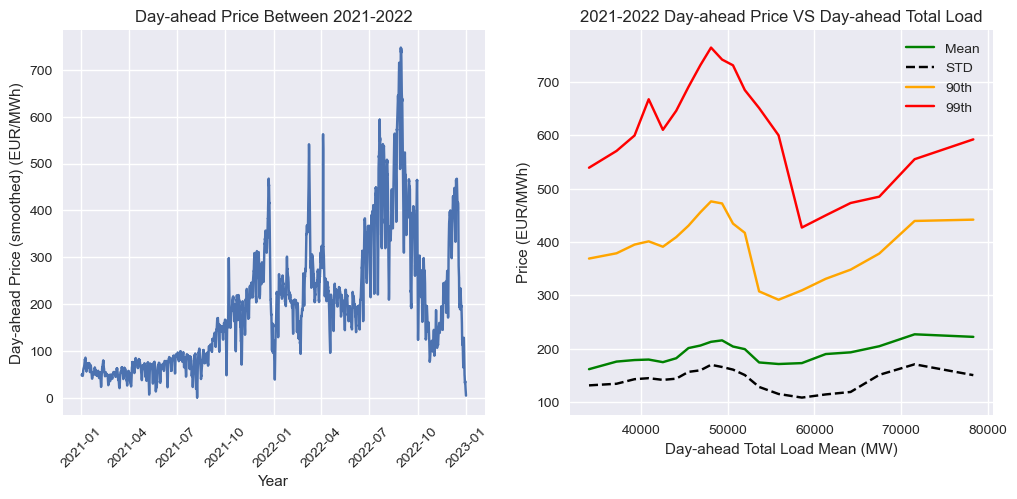

In [82]:
fig, axs = plt.subplots(ncols = 2, figsize = [12,5])
sns.lineplot(data = df_2021_2022, x = df_2021_2022.index, y = "price_smooth", ax = axs[0])
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_mean", ax = axs[1], label = "Mean", color = "green")
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_std", ax = axs[1], label = "STD", color = "black", ls = "--")
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_90th", ax = axs[1], label = "90th", color = "orange")
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_99th", ax = axs[1], label = "99th", color = "red")
axs[0].tick_params("x", rotation = 45)
axs[0].set_ylabel("Day-ahead Price (smoothed) (EUR/MWh)")
axs[0].set_xlabel("Year")
axs[0].set_title("Day-ahead Price Between 2021-2022")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[1].set_xlabel("Day-ahead Total Load Mean (MW)")
axs[1].set_title("2021-2022 Day-ahead Price VS Day-ahead Total Load")
plt.show()

In [83]:
df_2023_2024_load_bins = df_2023_2024.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2023_2024_load_bins.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(27649.999, 34450.0]",32597.916667,49.064617,33.136427,91.493,105.5028
"(34450.0, 36550.0]",35565.188000,49.510069,36.145339,94.760,110.1778
"(36550.0, 38350.0]",37559.085407,52.776425,39.576542,100.000,118.0903
"(38350.0, 39900.0]",39156.746857,57.629646,41.489194,107.344,130.9014
"(39900.0, 41400.0]",40694.031465,59.960744,43.222656,111.522,135.6006


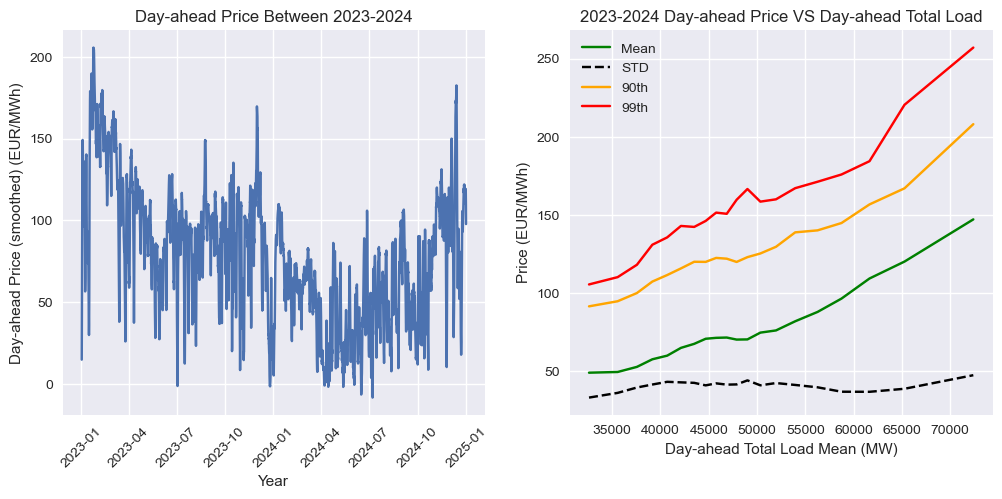

In [84]:
fig, axs = plt.subplots(ncols = 2, figsize = [12,5])
sns.lineplot(data = df_2023_2024, x = df_2023_2024.index, y = "price_smooth", ax = axs[0])
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_mean", ax = axs[1], label = "Mean", color = "green")
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_std", label = "STD", ls = "--", ax = axs[1], color = "black")
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_90th", ax = axs[1], color = "orange", label = "90th")
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_99th", ax = axs[1], label = "99th", color = "red")
axs[0].tick_params("x", rotation = 45)
axs[0].set_ylabel("Day-ahead Price (smoothed) (EUR/MWh)")
axs[0].set_xlabel("Year")
axs[0].set_title("Day-ahead Price Between 2023-2024")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[1].set_xlabel("Day-ahead Total Load Mean (MW)")
axs[1].set_title("2023-2024 Day-ahead Price VS Day-ahead Total Load")
plt.show()

#### Load is a good price predictor in normal markets but becomes uninformative during structural shocks, e.g. 2022 energy crisis.

## Negative prices

In [85]:
negative_price = df_alls[df_alls["Day-ahead Price (EUR/MWh)"] < 0].copy()

In [86]:
negative_price["Day-ahead Price (EUR/MWh)"].count()

np.int64(713)

#### Negative price VS Hour of the day

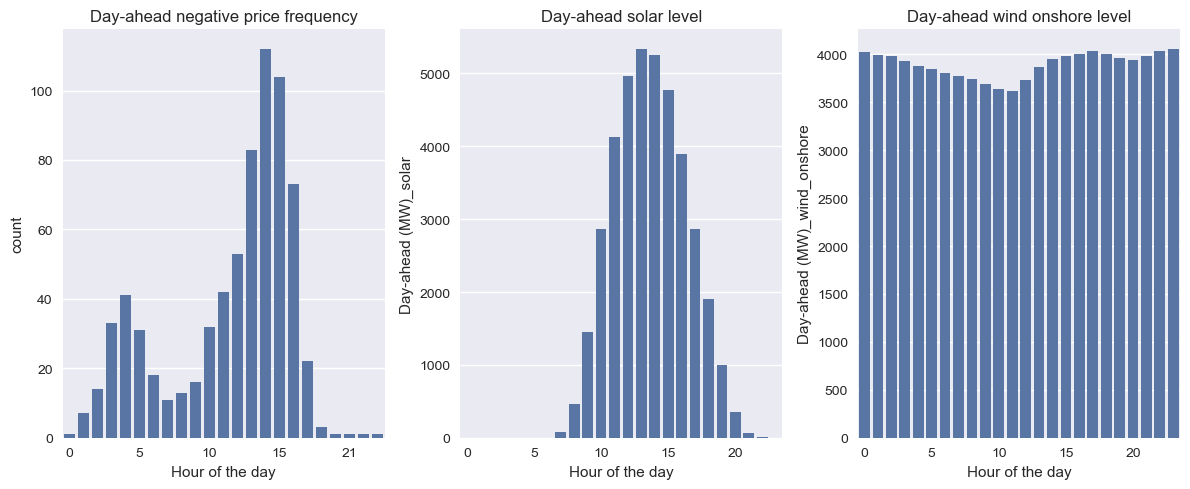

In [87]:
neg_price_hour = negative_price.index.hour.value_counts().sort_index().reset_index()
df_solar_pred_hour = df_alls.groupby(df_alls.index.hour)["Day-ahead (MW)_solar"].mean().reset_index()
df_wind_onshore_hour = df_alls.groupby(df_alls.index.hour)["Day-ahead (MW)_wind_onshore"].mean().reset_index()

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 5))
sns.barplot(data = neg_price_hour, x = "timestamp", y = "count", ax = axes[0])
axes[0].set_title("Day-ahead negative price frequency")
axes[0].set_xlabel("Hour of the day")
axes[0].set_xticks(range(0, 24, 5))
sns.barplot(data = df_solar_pred_hour, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1])
axes[1].set_xlabel("Hour of the day")
axes[1].set_title("Day-ahead solar level")
axes[1].set_xticks(range(0, 24, 5))
sns.barplot(data = df_wind_onshore_hour, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2])
axes[2].set_xlabel("Hour of the day")
axes[2].set_title("Day-ahead wind onshore level")
axes[2].set_xticks(range(0, 24, 5))
plt.tight_layout()
plt.show()

**Wind doesn't cause negative prices the way solar does.** <br>
- At night, energy production sources are wind, gas or hydro, all partially dispatchable. Therefore, the grid can absort nighttime wind without prices going negative.  <br>
- During the day, solar coexist with nuclear, and both forms cannot easily reduce output. Therefore, the collision creates negative prices.

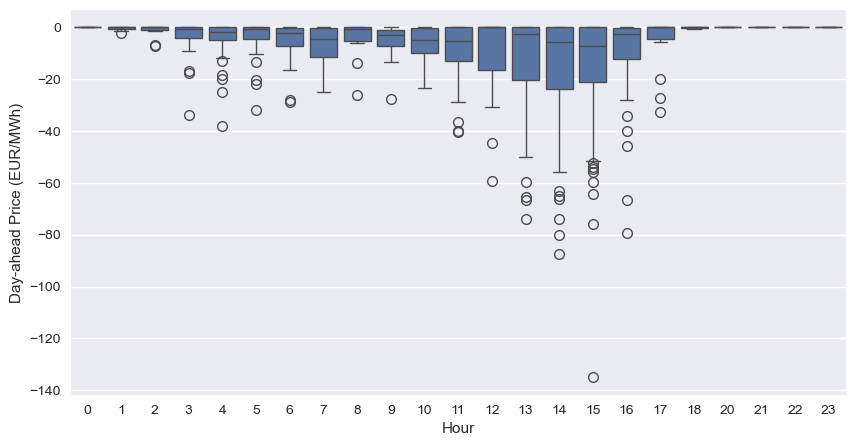

In [88]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.hour, y = "Day-ahead Price (EUR/MWh)")
plt.xlabel("Hour")
plt.show()

#### Negative price VS Day of the week

In [89]:
neg_price_week = negative_price.index.dayofweek.value_counts().sort_index()
neg_price_week.index = neg_price_week.index.map(weekday_map)
df_solar_pred_week = df_alls.groupby(df_alls.index.dayofweek)["Day-ahead (MW)_solar"].mean().sort_index()
df_solar_pred_week.index = df_solar_pred_week.index.map(weekday_map)
df_solar_pred_week = df_solar_pred_week.reset_index()
df_wind_onshore_week = df_alls.groupby(df_alls.index.dayofweek)["Day-ahead (MW)_wind_onshore"].mean().sort_index()
df_wind_onshore_week.index = df_wind_onshore_week.index.map(weekday_map)
df_wind_onshore_week = df_wind_onshore_week.reset_index()

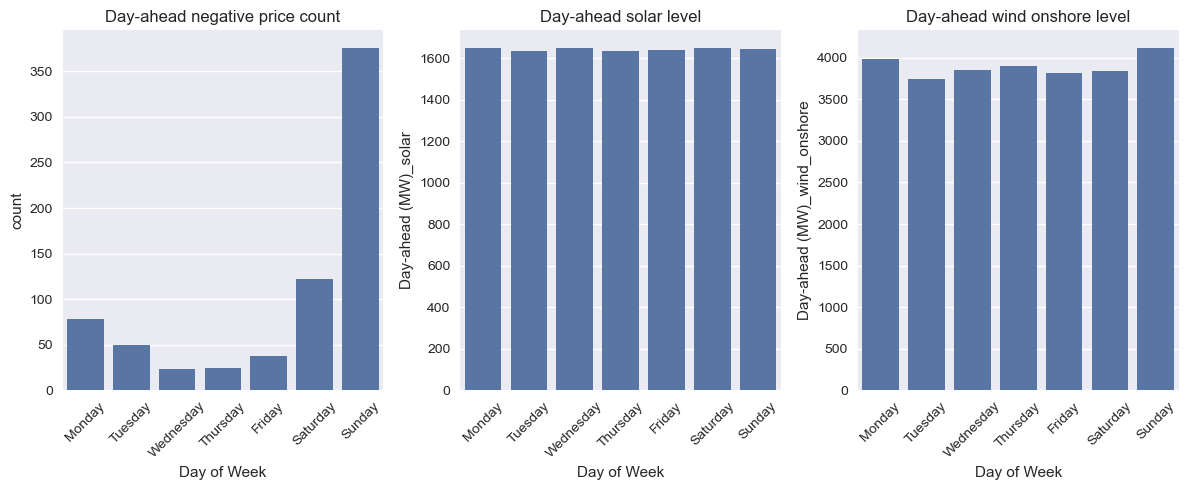

In [90]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12,5))
sns.barplot(data = neg_price_week.reset_index(), x = "timestamp", y = "count", ax = axes[0])
axes[0].set_title("Day-ahead negative price count")
axes[0].set_xlabel("Day of Week")
axes[0].tick_params("x", rotation = 45)
sns.barplot(data = df_solar_pred_week, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1])
axes[1].tick_params("x", rotation = 45)
axes[1].set_xlabel("Day of Week")
axes[1].set_title("Day-ahead solar level")
sns.barplot(data = df_wind_onshore_week, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2])
axes[2].tick_params("x", rotation = 45)
axes[2].set_xlabel("Day of Week")
axes[2].set_title("Day-ahead wind onshore level")
plt.tight_layout()
plt.show()

**Sunday demand trough + must-run supply = negative price**

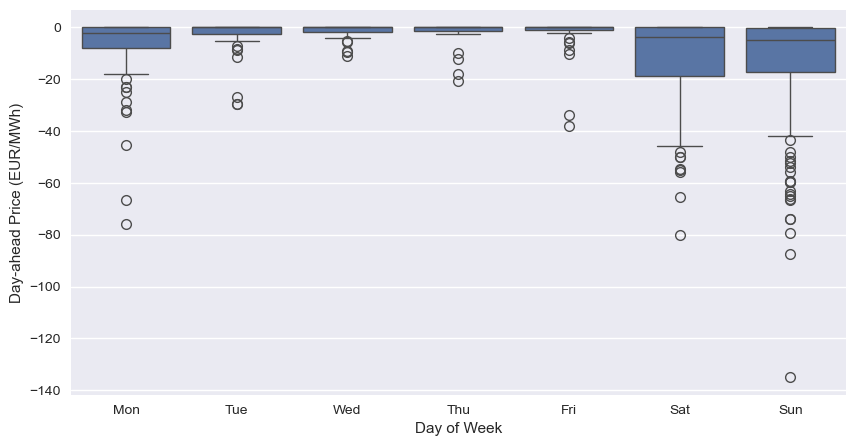

In [91]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.dayofweek, y = "Day-ahead Price (EUR/MWh)")
plt.xlabel("Day of Week")
plt.xticks(range(0, 7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

#### Negative price VS Month

In [92]:
neg_price_month = negative_price.index.month.value_counts().sort_index().reset_index()
df_solar_pred_month = df_alls.groupby(df_alls.index.month)["Day-ahead (MW)_solar"].mean().sort_index()
df_solar_pred_month = df_solar_pred_month.reset_index()
df_wind_onshore_month = df_alls.groupby(df_alls.index.month)["Day-ahead (MW)_wind_onshore"].mean().sort_index()
df_wind_onshore_month = df_wind_onshore_month.reset_index()

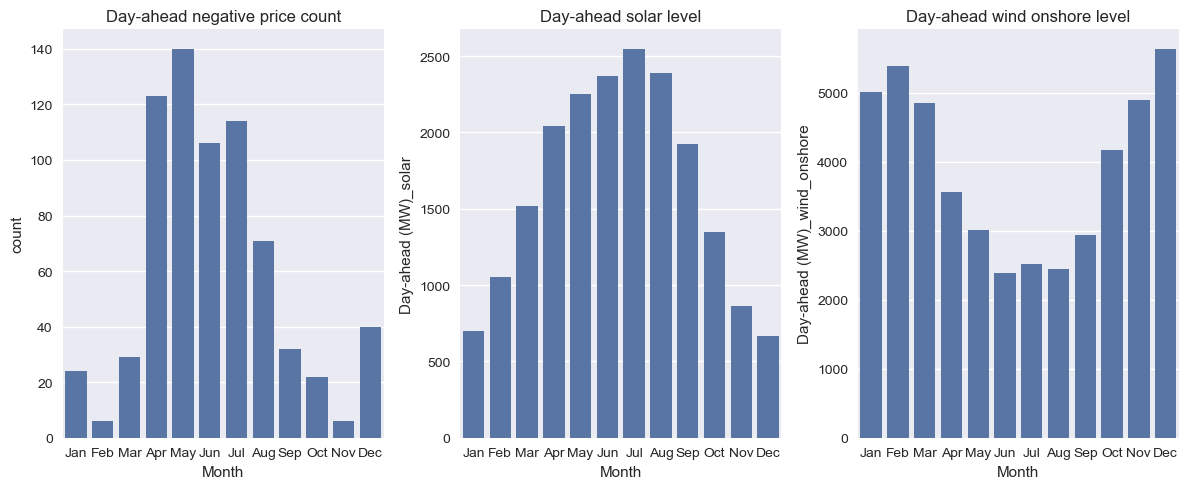

In [93]:
fig, axes = plt.subplots(ncols = 3, nrows = 1, figsize = (12, 5))
sns.barplot(data = neg_price_month, x = "timestamp", y = "count", ax = axes[0])
axes[0].set_title("Day-ahead negative price count")
axes[0].set_xlabel("Month")
axes[0].set_xticks(range(0, 12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

sns.barplot(data = df_solar_pred_month, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1])
axes[1].set_title("Day-ahead solar level")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(0, 12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
sns.barplot(data = df_wind_onshore_month, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2])
axes[2].set_title("Day-ahead wind onshore level")
axes[2].set_xlabel("Month")
axes[2].set_xticks(range(0, 12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.tight_layout()
plt.show()

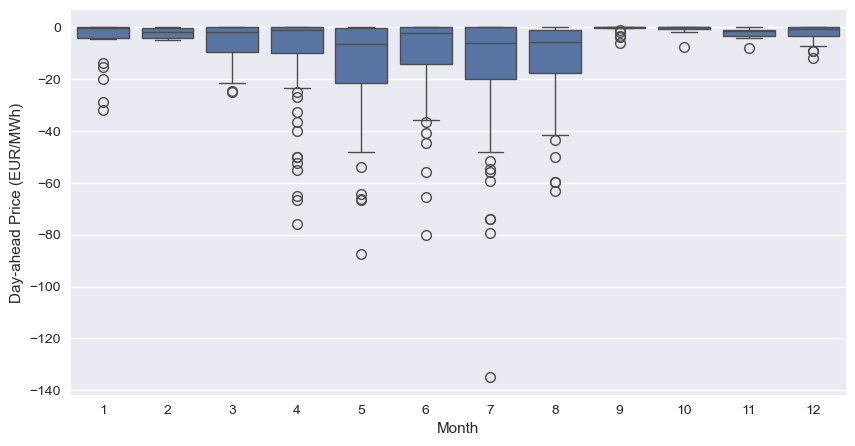

In [94]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.month, y = "Day-ahead Price (EUR/MWh)")
plt.xlabel("Month")
plt.show()

#### Negative price VS Year

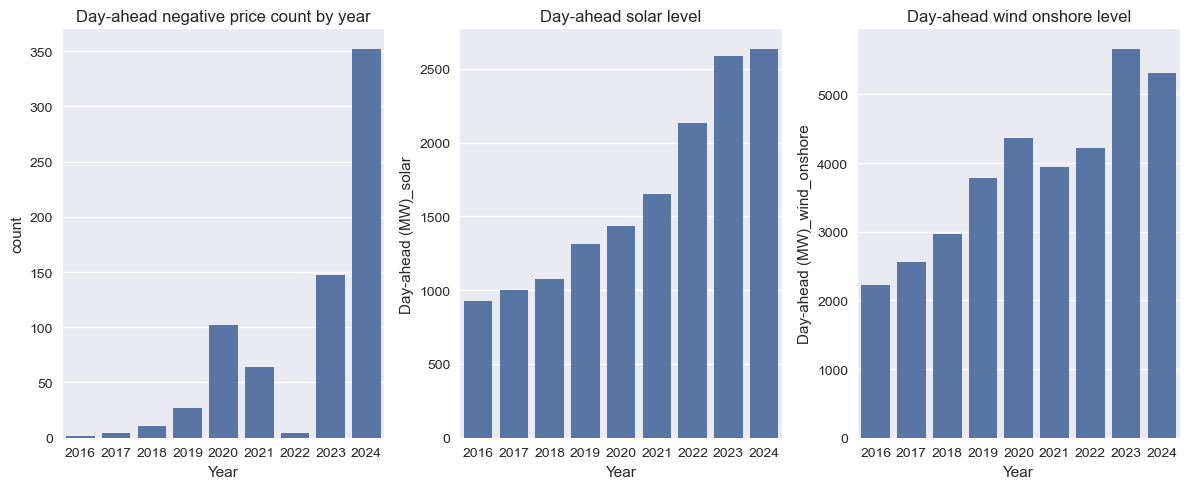

In [95]:
neg_price_year = negative_price.index.year.value_counts().sort_index().reset_index()
df_solar_pred_year = df_alls.groupby(df_alls.index.year)["Day-ahead (MW)_solar"].mean().sort_index().reset_index()
df_wind_onshore_year = df_alls.groupby(df_alls.index.year)["Day-ahead (MW)_wind_onshore"].mean().sort_index().reset_index()

fig, axes = plt.subplots(ncols = 3, nrows = 1, figsize = (12, 5))
sns.barplot(data = neg_price_year, x = "timestamp", y = "count", ax = axes[0])
axes[0].set_title("Day-ahead negative price count by year")
axes[0].set_xlabel("Year")
sns.barplot(data = df_solar_pred_year, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1])
axes[1].set_title("Day-ahead solar level")
axes[1].set_xlabel("Year")
sns.barplot(data = df_wind_onshore_year, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2])
axes[2].set_title("Day-ahead wind onshore level")
axes[2].set_xlabel("Year")
plt.tight_layout()
plt.show()

During 2022 the energy crisis, gas prices was so high that solar surplus was absorbed. 

#### Trend of negative prices

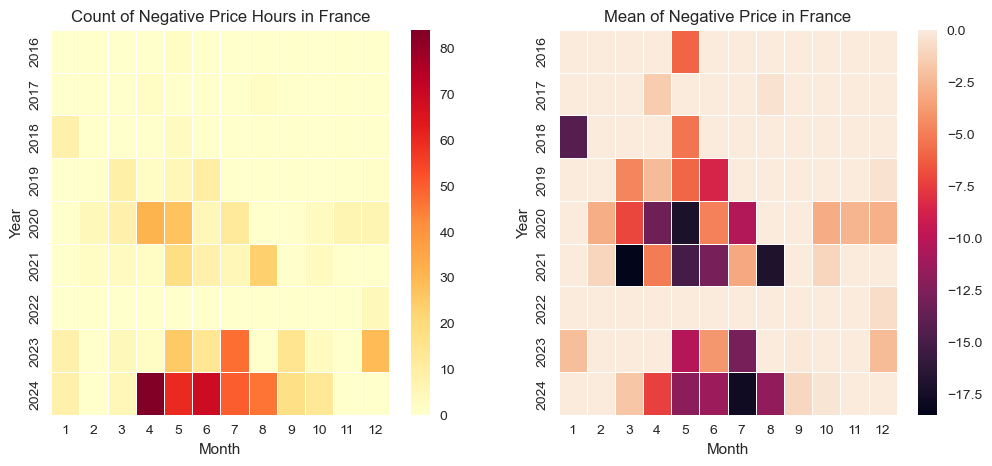

In [99]:
negative_price_year_month_count = (negative_price.groupby([negative_price.index.year, negative_price.index.month])
                             ["Day-ahead Price (EUR/MWh)"].count().unstack(level = 1).fillna(0))
negative_price_year_month_mean = (negative_price.groupby([negative_price.index.year, negative_price.index.month])
                             ["Day-ahead Price (EUR/MWh)"].mean().unstack(level = 1).fillna(0))

fig, axes = plt.subplots(ncols = 2, figsize = (12, 5))
sns.heatmap(negative_price_year_month_count, cmap = "YlOrRd", linewidth = 0.5, annot = False, ax = axes[0])
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")
axes[0].set_title("Count of Negative Price Hours in France")
sns.heatmap(negative_price_year_month_mean, cmap = "rocket", linewidth = 0.5, annot = False, ax = axes[1])
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Year")
axes[1].set_title("Mean of Negative Price in France")

plt.show()

A trend of more months with more negative prices in recent years is showing. The mean negative price shows an increasing trend in recent years as well (exclude 2022). 

#### Negative price magnitude by year

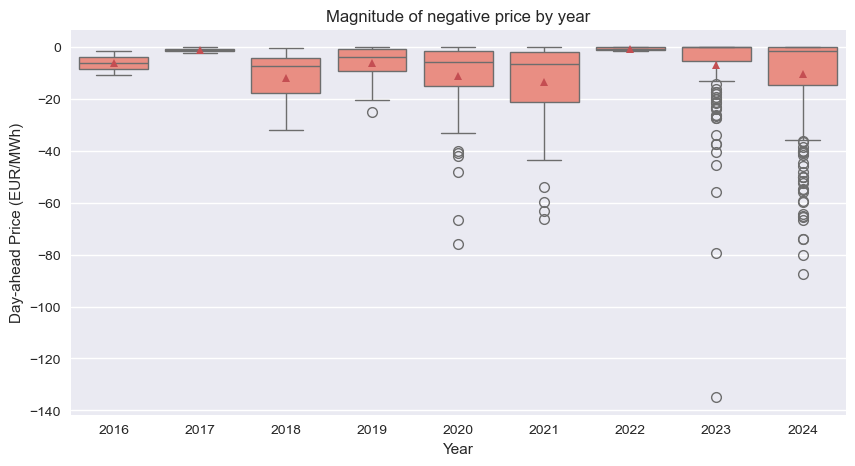

In [100]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.year, y = "Day-ahead Price (EUR/MWh)", color = "salmon", showmeans = True)
plt.title("Magnitude of negative price by year")
plt.xlabel("Year")
plt.show()

#### Conclusion of Negative Price Analysis

Negative prices in France is caused by the interaction between renewable expansion, inflexible baseload nuclear generation, weak electricity demand, and limited storage flexibility. In particular, solar generation appears to be the strongest recurring driver, while wind contributes more irregularly through weather-dependent variability.

## Forecast error

### Day-ahead & Actual Wind Load (Off-shore) vs Time

In [101]:
df_alls["Day-ahead (MW)_wind_offshore"] = df_alls["Day-ahead (MW)_wind_offshore"].astype(float)
df_alls["Day-ahead (MW)_wind_offshore"].isna().sum()

np.int64(66599)

In [102]:
df_alls["Actual (MW)_wind_offshore"].isna().sum()

np.int64(65403)

In [103]:
df_alls["Actual (MW)_wind_offshore"] = df_alls["Actual (MW)_wind_offshore"].replace(" ", np.nan)
df_alls["Actual (MW)_wind_offshore"] = df_alls["Actual (MW)_wind_offshore"].astype(float)

In [104]:
df_alls["Day-ahead (MW)_wind_offshore"].first_valid_index()

Timestamp('2023-08-07 00:00:00+0200', tz='Europe/Paris')

In [105]:
df_alls["Actual (MW)_wind_offshore"].first_valid_index()

Timestamp('2023-06-01 00:00:00+0200', tz='Europe/Paris')

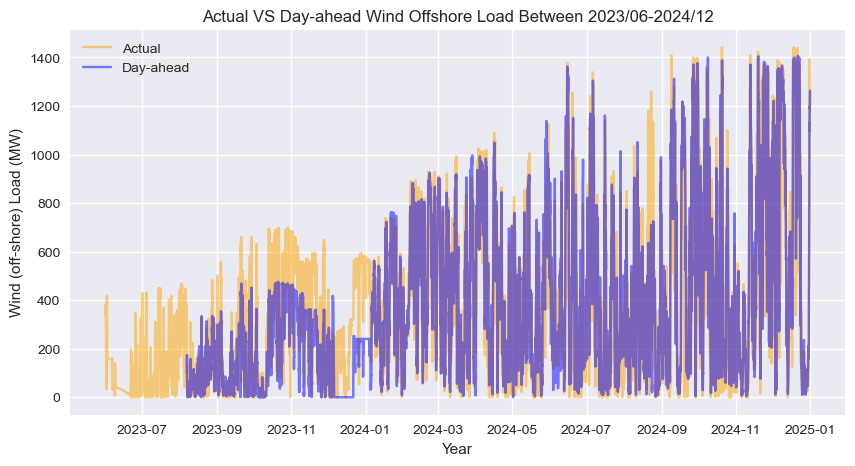

In [106]:
plt.figure(figsize = (10, 5))
sns.lineplot(data = df_alls, x = df_alls.index, y = "Actual (MW)_wind_offshore", alpha = 0.5, color = "orange", label = "Actual")
sns.lineplot(data = df_alls, x = df_alls.index, y = "Day-ahead (MW)_wind_offshore", alpha = 0.5, color = "blue", label = "Day-ahead")
plt.legend()
plt.title("Actual VS Day-ahead Wind Offshore Load Between 2023/06-2024/12")
plt.xlabel("Year")
plt.ylabel("Wind (off-shore) Load (MW)")
plt.show()

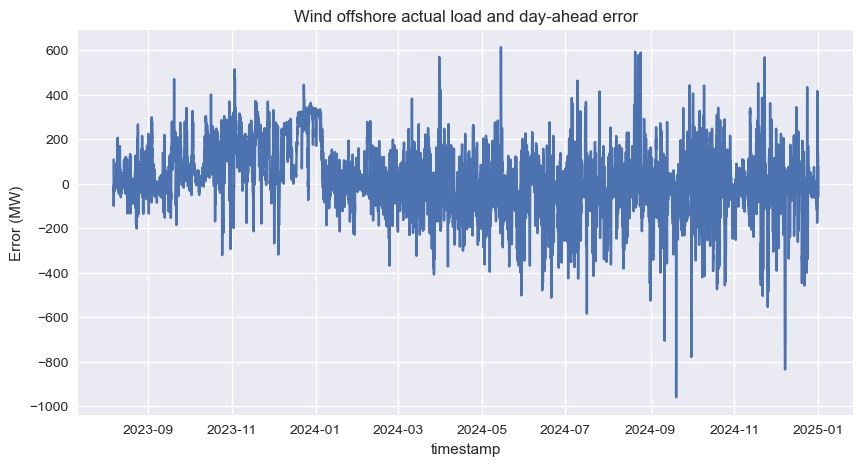

In [107]:
wind_offshore_err = (df_alls["Actual (MW)_wind_offshore"] - df_alls["Day-ahead (MW)_wind_offshore"]).reset_index()
wind_offshore_err.columns = ["timestamp", "error"]

plt.figure(figsize = (10, 5))
sns.lineplot(data = wind_offshore_err, x = "timestamp", y = "error")
plt.ylabel("Error (MW)")
plt.title("Wind offshore actual load and day-ahead error")
plt.show()

In [108]:
wind_offshore_err = (df_alls["Actual (MW)_wind_offshore"] - df_alls["Day-ahead (MW)_wind_offshore"])
wind_offshore_err.describe()

count    12290.000000
mean        19.350171
std        143.530095
min       -959.250000
25%        -53.000000
50%          7.250000
75%         88.000000
max        613.000000
dtype: float64

Wind offshore load was systematically slightly underforecast with a moderate variability. 

In [109]:
negative_price["Actual (MW)_wind_offshore"] = negative_price["Actual (MW)_wind_offshore"].astype(float)
negative_price["Day-ahead (MW)_wind_offshore"] = negative_price["Day-ahead (MW)_wind_offshore"].astype(float)
negative_price["wind_offshore_err"] = (negative_price["Actual (MW)_wind_offshore"] - negative_price["Day-ahead (MW)_wind_offshore"])
negative_price["wind_offshore_err"].describe()

count    399.000000
mean      28.251880
std      156.972724
min     -381.500000
25%      -69.125000
50%       -0.500000
75%      115.875000
max      517.750000
Name: wind_offshore_err, dtype: float64

In the case of negative price, wind offshore load was slightly underforecasted with a moderate variability.

### Day-ahead & Actual Wind Load (On-shore) vs Time

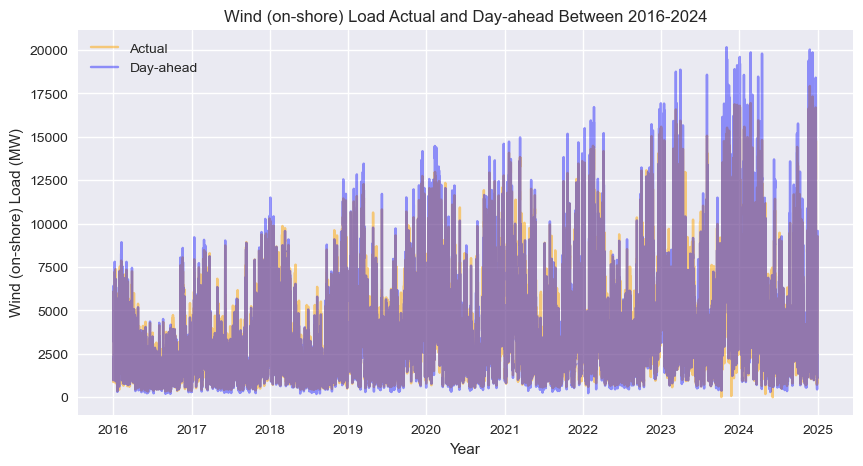

In [110]:
plt.figure(figsize = (10, 5))
sns.lineplot(data = df_alls, x = df_alls.index, y = "Actual (MW)_wind_onshore", alpha = 0.5, color = "orange", label = "Actual")
sns.lineplot(data = df_alls, x = df_alls.index, y = "Day-ahead (MW)_wind_onshore", alpha = 0.4, color = "blue", label = "Day-ahead")
plt.legend()
plt.title("Wind (on-shore) Load Actual and Day-ahead Between 2016-2024")
plt.xlabel("Year")
plt.ylabel("Wind (on-shore) Load (MW)")
plt.show()

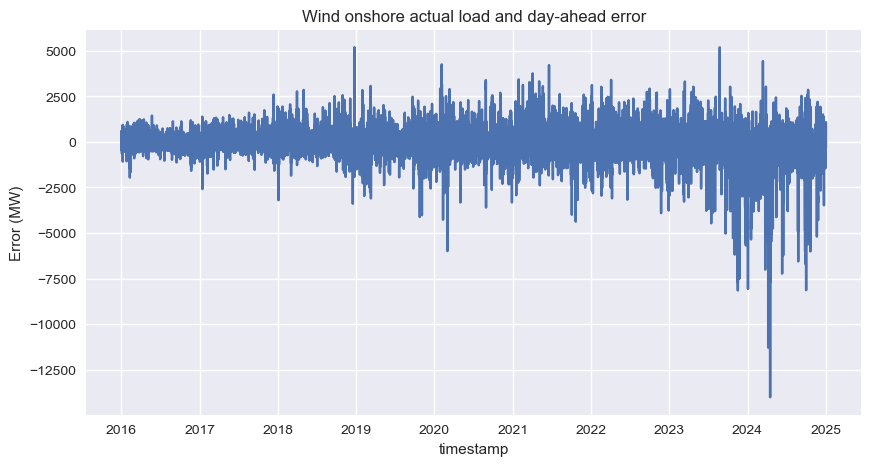

In [111]:
wind_onshore_err = (df_alls["Actual (MW)_wind_onshore"] - df_alls["Day-ahead (MW)_wind_onshore"]).reset_index()
wind_onshore_err.columns = ["timestamp", "error"]

plt.figure(figsize = (10, 5))
sns.lineplot(data = wind_onshore_err, x = "timestamp", y = "error")
plt.ylabel("Error (MW)")
plt.title("Wind onshore actual load and day-ahead error")
plt.show()

In [112]:
wind_onshore_err = (df_alls["Actual (MW)_wind_onshore"] - df_alls["Day-ahead (MW)_wind_onshore"])
wind_onshore_err.describe()

count    78371.000000
mean       -74.988155
std        742.532826
min     -14007.620000
25%       -342.720000
50%        -29.430000
75%        255.725000
max       5194.920000
dtype: float64

Wind onshore load was slightly overforecast. The variability is larger than the bias. 

In [113]:
wind_onshore_err.groupby(wind_onshore_err.index.year).mean()

timestamp
2016     -1.733977
2017     52.536930
2018     89.621151
2019    -40.168398
2020     22.492463
2021     55.838875
2022     -1.895346
2023   -303.413978
2024   -542.677635
dtype: float64

In [114]:
wind_onshore_err.groupby(wind_onshore_err.index.year).std()

timestamp
2016     318.600326
2017     372.286537
2018     524.015155
2019     598.436230
2020     689.335183
2021     725.617916
2022     685.984722
2023     976.902027
2024    1139.563012
dtype: float64

In [115]:
negative_price["wind_onshore_err"] = (negative_price["Actual (MW)_wind_onshore"] - negative_price["Day-ahead (MW)_wind_onshore"])
negative_price["wind_onshore_err"].describe()

count      710.000000
mean     -1742.184662
std       2407.666839
min     -14007.620000
25%      -2706.667500
50%       -787.160000
75%       -167.542500
max       1941.740000
Name: wind_onshore_err, dtype: float64

In the case of negative prices, wind onshore load was strongly overforecasted, and the variability is large. 

### Day-ahead & Actual Solar Load vs Time

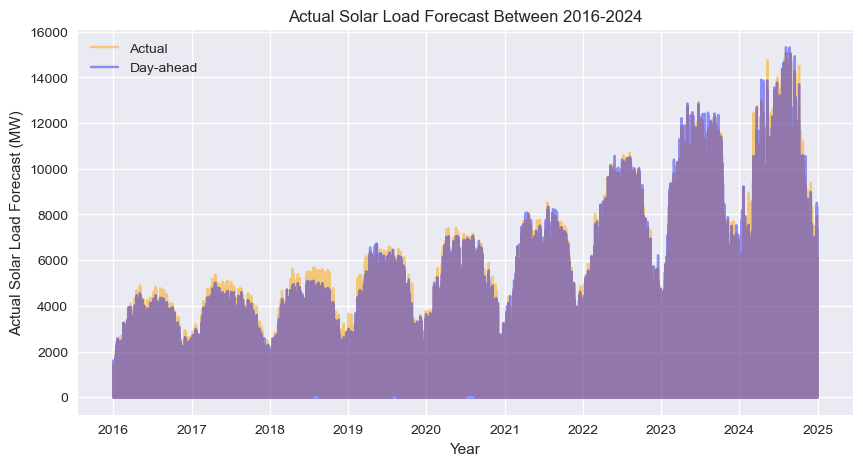

In [116]:
plt.figure(figsize = (10, 5))
sns.lineplot(data = df_alls, x = df_alls.index, y = "Actual (MW)_solar", color = "orange", alpha = 0.5, label = "Actual")
sns.lineplot(data = df_alls, x = df_alls.index, y = "Day-ahead (MW)_solar", color = "blue", alpha = 0.4, label = "Day-ahead")
plt.legend()
plt.title("Actual Solar Load Forecast Between 2016-2024")
plt.xlabel("Year")
plt.ylabel("Actual Solar Load Forecast (MW)")
plt.show()

In [117]:
solar_err = (df_alls["Actual (MW)_solar"] - df_alls["Day-ahead (MW)_solar"])
solar_err.describe()

count    78346.000000
mean       -29.843414
std        606.170700
min      -6761.370000
25%        -71.327500
50%          0.000000
75%        120.000000
max       4284.930000
dtype: float64

Solar load was slightly biased in forecasting, with a moderate forecast varibility. 

In [118]:
solar_err.groupby(solar_err.index.year).mean()

timestamp
2016     -7.779147
2017     13.822996
2018     31.796529
2019     -7.687253
2020    -19.617809
2021    -87.770562
2022    -77.563826
2023   -133.084800
2024     19.289324
dtype: float64

In [119]:
solar_err.groupby(solar_err.index.year).std()

timestamp
2016    247.634319
2017    260.767339
2018    320.412959
2019    381.355337
2020    398.338591
2021    946.930780
2022    617.449353
2023    753.713303
2024    944.823086
dtype: float64

In [120]:
negative_price["solar_err"] = (negative_price["Actual (MW)_solar"] - negative_price["Day-ahead (MW)_solar"])
negative_price["solar_err"].describe()

count     710.000000
mean    -1362.997028
std      1595.831810
min     -6761.370000
25%     -2460.482500
50%     -1015.080000
75%         0.000000
max      2205.050000
Name: solar_err, dtype: float64

in the event of negative price, solar load was strongly overforecasted with a large variablity. 

### Forecast error is not the main driver for negative price.

The forecast error analysis of wind onshore and solar generation for the full dataset shows that both technologies exhibit a small but systematic negative mean error, indicating that day-ahead forecasts tend to slightly overpredict actual renewable generation. The large standard deviation suggests that forecast uncertainty has more variability than persistent bias.

During negative-price periods, both wind onshore and solar forecast errors become substantially more negative, with significantly larger standard deviations. This indicates that negative-price events often occur even when actual renewable generation is lower than forecasted, rather than during unexpected renewable surpluses.

These results suggest that forecast error alone is not the dominant driver of negative electricity prices in France. Forecast errors may still contribute to short-term market volatility and the severity of extreme events, but they appear to play a secondary role compared to broader system-level supply-demand imbalance. 

# Key findings

6-8 bullet points